# Histopathologic Cancer Detection

### Problem Overview:
In this 2018-2019 Kaggle competition, I was challenged with developing machine learning models to identify cancerous tissue within digital pathology scans. The images contain small, square patches extracted and deduplicated from the larger PatchCamelyon (PCam) benchmark. These patches are taken from whole slide images (WSIs) and represent a important area of focus in cancer diagnostics. The task was to create a binary classification model that could accurately classify between cancerous (positive) and non-cancerous (negative) tissue samples. There are very subtle visual differences between these two classes, which presents a significant challenge in machine learning and computer vision. Kaggle evaluates each submission using the Area Under the Receiver Operating Characteristic curve (AUC ROC). This metric evaluates the model's ability to segregate between the two classes across a range of classification thresholds. It is calculated by comparing the model's predicted probability of cancer for each image with the ground truth label. A higher AUC ROC score indicates better performance in identifying cancerous regions.

### Dataset:
The 7.76 GB dataset consists of 277,485 files, including two csv files and two folders named test and train that contain the .tif images. Files are named with an image id and the train_labels.csv file has the ground truth labels for the train images. The sample_submission.csv file provides an outline of how model outputs should be structured. The first column should have the image id and the second column with the label (0 or 1).There are 220,025 total train images and 57458 test images to use for predictions. 

### Dependencies

In [ ]:
# standard
import os
import random
import datetime
from multiprocessing import Pool, cpu_count

# data handling and calculations
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# machine learning 
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# deep learning and TensorFlow/Keras
import tensorflow as tf
# from tensorflow.keras.applications import EfficientNetV2S, preprocess_input
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2S, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, LayerNormalization, MultiHeadAttention, Flatten, Add, Reshape, Embedding
from tensorflow.keras.layers import Layer
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.metrics import AUC
from tensorflow.keras.mixed_precision import LossScaleOptimizer

# image processing
import cv2
import glob

# optimization
import optuna
from optuna.integration import KerasPruningCallback

# progress bar utility
from tqdm import tqdm


In [3]:
# !pip install spams-bin

In [4]:
train_labels_path = pd.read_csv('/workspace/data/train_labels.csv')
train_path = '/workspace/data/train/'
test_path = '/workspace/data/test/'

### GPU Setup

In [5]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '0' # set log level to show all logs

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("CUDA available:", tf.test.is_built_with_gpu_support())
print(tf.config.list_physical_devices('GPU'))
# list all GPUs
gpus = tf.config.list_physical_devices('GPU')

# check compute capability if GPU available
if gpus:
    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        print(f"Device: {gpu.name}")
        print(f"Compute Capability: {details.get('compute_capability')}")
else:
    print("No GPU found.")

TensorFlow version: 2.13.0
Built with CUDA: True
CUDA available: True
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device: /physical_device:GPU:0
Compute Capability: (8, 6)


2025-08-28 02:48:45.196622: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-28 02:48:45.217438: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-28 02:48:45.217647: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-28 02:48:45.218346: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [6]:
# config GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Exploratory Data Analysis (EDA) and Preprocessing 
Here, I explore the data looking for any patterns that could give me clues on how to preprocess the images, clean the data, and setup my model architecture. I also preprocess my images.

### Label Counts and Image Size

Here, I look at the counts of labels to get a sense of class balance. The training set contains 130,908 non-cancerous images and 89,117 cancerous images. This means 59.5% of the images are labeled 0 and the remeaining 40.5% are labeled 1. Since the minority class is not less than 20% of the data, I believe we will not need to implement resampling techniques. There is slight class imbalance, but I do not believe it will impact model performance. 

Using CV2, I read the first image to find its shape and find that it is 96x96x3.

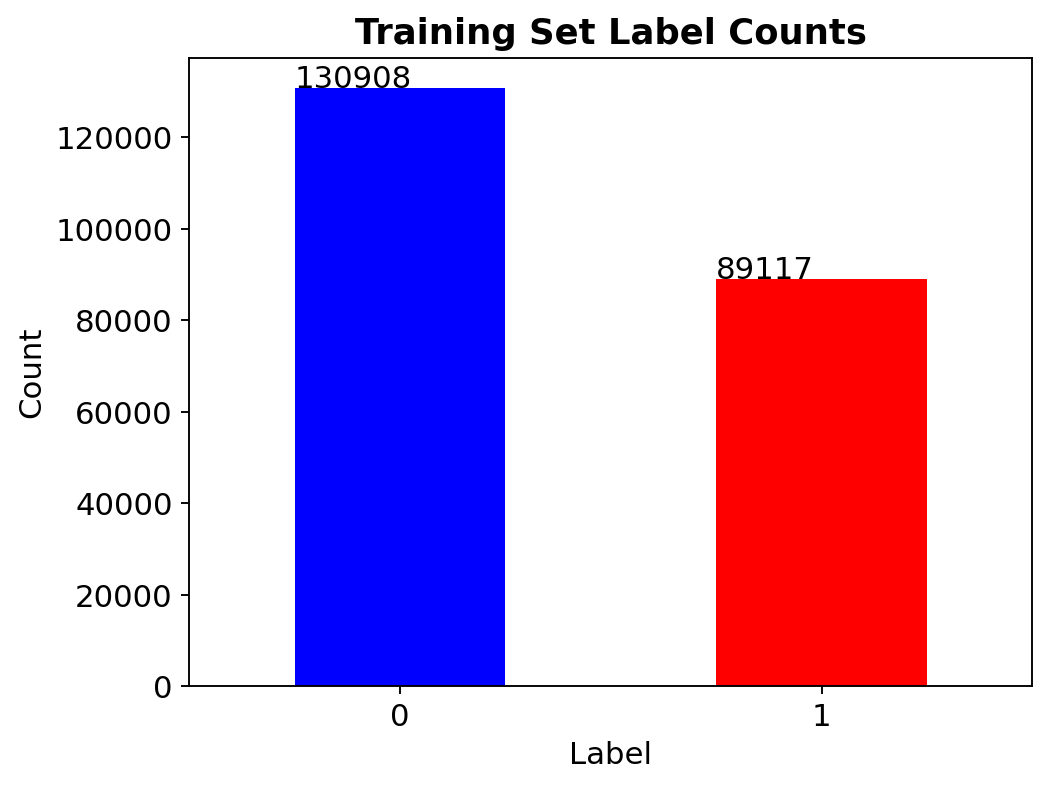

Image Height: 96
Image Width: 96
Number of Color Channels (BGR): 3


In [37]:
# look at the label stats
label_counts = train_labels_path['label'].value_counts()

# Create the bar plot
label_counts.plot(kind='bar', color=['blue', 'red']) 
plt.title("Training Set Label Counts")
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0, 1], rotation=0) 
for p in plt.gca().patches: 
    plt.annotate(str(p.get_height()), (p.get_x(), p.get_height()))
plt.show()

# look at image size: get a list of image file names in the training data
image_filenames = [img for img in os.listdir(train_path) if img.endswith('.tif')]

# read the first image
train_img_1 = cv2.imread(os.path.join(train_path, image_filenames[0]))

# get the height and width
height, width, num_color_channels = train_img_1.shape
print("Image Height:", height)
print("Image Width:", width)
print("Number of Color Channels (BGR):", num_color_channels)

### Corrupted Image Check

Now, I will check for corrupted images across the entire dataset. I loop through all images in training path and testing path and attempt to open each image with cv2.imread(). I log and count any images that fail to load then save the list of corrupted image IDs to inspect. Thankfully, there were no corrupted images!

In [ ]:
def is_corrupted(img_path):
    """function to check if an image is corrupted"""
    img = cv2.imread(img_path)
    return img is None

# file paths for training and testing
train_image_paths = [os.path.join(train_path, f"{img_id}.tif") for img_id in train_labels_path['id']]
test_image_paths = [os.path.join(test_path, img_file) for img_file in os.listdir(test_path)]

def check_corrupted_images(image_paths):
    with Pool(cpu_count()) as pool:
        results = pool.map(is_corrupted, image_paths)
    return [image_paths[i] for i, corrupted in enumerate(results) if corrupted]

# check corrupted images in parallel
corrupted_train_images = check_corrupted_images(train_image_paths)
corrupted_test_images = check_corrupted_images(test_image_paths)

# summarize results
num_corrupted_train = len(corrupted_train_images)
num_corrupted_test = len(corrupted_test_images)
num_total_train = len(train_labels_path)
num_total_test = len(test_image_paths)

corrupted_image_data = {"Total Train Images": num_total_train,
                        "Corrupted Train Images": num_corrupted_train,
                        "Corrupted Train Image IDs": [os.path.basename(p).split(".")[0] for p in corrupted_train_images[:5]],
                        "Total Test Images": num_total_test,
                          "Corrupted Test Images": num_corrupted_test,
                          "Corrupted Test Image IDs": [os.path.basename(p) for p in corrupted_test_images[:5]]
                          }

corrupted_image_data

### Image Format Conversion and Positive/Negative Sample Visualization

The function read_image reads an image using cv2.imread and converts it to RGB format. OpenCV loads images in BGR format by default, not RGB. The conversion using: **cv2.cvtColor(img, cv2.COLOR_BGR2RGB)** is required because most libraries like Matplotlib expect RGB format for correct visualization. Blueboxes indicate negative samples with no tumor present (0), while red boxes indicate positive samples with tumor present (1). After visualizing the images, I instantly notice a lot of variation in staining. Some images contain nearly no staining, while others arevery dark purple. This clues me in to performing stain normalization so that my model does not pick up on the human error introduced from staining, but rather the actual cell morphology when looking for cancerous cells. 

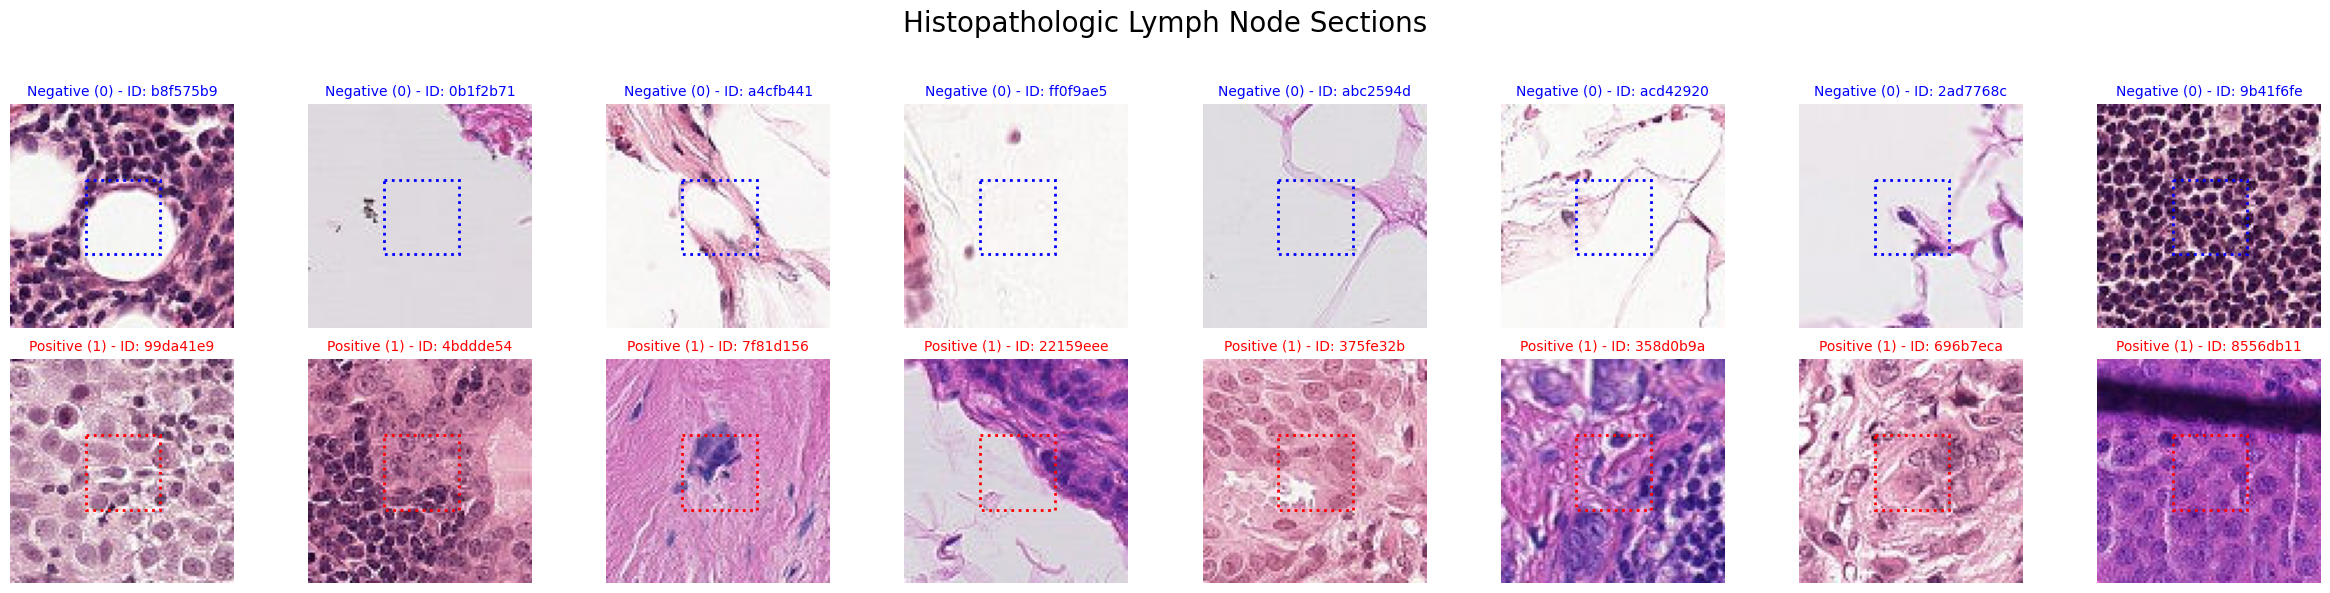

In [8]:
def read_image_visual(path):
    """function to read and convert image to RGB"""
    img = cv2.imread(path)
    if img is None:
        print(f"Warning: Unable to load image {path}")
        return np.zeros((96,96,3), dtype=np.uint8) # return a black image if error
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0 # normalize for better visualization

# sample images 
negative_samples = train_labels_path[train_labels_path['label'] == 0].sample(n=8, random_state=100)
positive_samples = train_labels_path[train_labels_path['label'] == 1].sample(n=8, random_state=100)

fig, ax = plt.subplots(2, 8, figsize=(24, 6)) 
fig.suptitle('Histopathologic Lymph Node Sections', fontsize=20)

# reduce spacing between subplots
plt.subplots_adjust(wspace=0.2, hspace=0.3) # reduce white space

# negative samples
for i, img_id in enumerate(negative_samples['id']):
    path = os.path.join(train_path, img_id + '.tif')
    ax[0, i].imshow(read_image_visual(path))
    ax[0, i].set_title(f"Negative (0) - ID: {img_id[:8]}", fontsize=10, color='blue')
    ax[0, i].axis('off')

    # add 32x32 center region box
    box = patches.Rectangle((32, 32), 32, 32, linewidth=2, edgecolor='b', facecolor='none', linestyle=':')
    ax[0, i].add_patch(box)

# positive samples
for i, img_id in enumerate(positive_samples['id']):
    path = os.path.join(train_path, img_id + '.tif')
    ax[1, i].imshow(read_image_visual(path))
    ax[1, i].set_title(f"Positive (1) - ID: {img_id[:8]}", fontsize=10, color='red')
    ax[1, i].axis('off')

    # add 32x32 center region box
    box = patches.Rectangle((32, 32), 32, 32, linewidth=2, edgecolor='r', facecolor='none', linestyle=':')
    ax[1, i].add_patch(box)

# optimize layout
plt.tight_layout(rect=[0, 0, 1, 0.95]) # adjust so title doesn't overlap
plt.show()

I noticed that there is a lot of variation in the staining of the slides. After, my first pass of my model, I also saw that many misclassified images, particularly, false negatives, were darker in stianing overall. So I decided to perform stain normalization during my preprcoessing.  

### Stain Normalization
Here, I find a well stained image to use as a reference for my stain normalization. I randomly sample 10,000 images and computer their median color. Then I find the image within those 10,000 that most closely matches this median color and save its path to best_refernce_img.

Here, I chose to use Macenko Normalization because it performs well on slides dyed with Hematoxylin and Eosin (H&E). Since images are coming from different sources we need accurate color representation. I actually added this in to my last run of the model after seeing that many of the false negative images contain large edge patterns and variations in staining and texture. Since this seemed to be contributing to misclassifcation, I thought stain normalization would reduce variance between slides. 

My function is modified from the StainTools library (https://github.com/Peter554/StainTools/tree/master) My function uses a single pipeline approach that uses an OD-based background threshold and SVD to calculate the principal stains. SstainTools uses on a Lab based luminosity mask and eigen decomposition to get the main stain axes. I modified the original method to simplify background removal (through OD threshold) and to fail gracefully by returning the original image if too few tissue pixels remain. This helps avoid  errors on slides with very little staining.

In [9]:
import spams

def read_image(path):
    """Read image using OpenCV and convert to RGB."""
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def luminosity_standardizer(img, percentile=95):
    """Standardize brightness based on LAB lightness channel."""
    img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    L = img_lab[:, :, 0].astype(float)
    p = np.percentile(L, percentile)
    img_lab[:, :, 0] = np.clip(255 * L / p, 0, 255).astype(np.uint8)
    return cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)


def get_tissue_mask(img, luminosity_threshold=0.8):
    """Generate tissue mask based on LAB lightness threshold."""
    img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    L = img_lab[:, :, 0] / 255.0
    return L < luminosity_threshold

# def get_tissue_mask(img, luminosity_threshold=0.8, od_beta=None):
#     lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
#     L = lab[:, :, 0].astype(np.float32) / 255.0
#     mask = (L < luminosity_threshold)
#     if od_beta is not None:
#         OD = RGB_to_OD(img)
#         mask &= np.all(OD > od_beta, axis=2)
#     return mask


def RGB_to_OD(I):
    """Convert RGB to Optical Density (OD) space."""
    I = I.astype(np.float32)
    I[I == 0] = 1
    return np.maximum(-np.log(I / 255), 1e-6)


def OD_to_RGB(OD):
    """Convert OD back to RGB."""
    OD = np.maximum(OD, 1e-6)
    return (255 * np.exp(-1 * OD)).astype(np.uint8)


def normalize_rows(A):
    """Normalize rows of a matrix."""
    return A / np.linalg.norm(A, axis=1, keepdims=True)


class MacenkoStainExtractor:
    @staticmethod
    def get_stain_matrix(I, luminosity_threshold=0.8, angular_percentile=99):
        assert I.dtype == np.uint8
        tissue_mask = get_tissue_mask(I, luminosity_threshold).reshape(-1)
        OD = RGB_to_OD(I).reshape((-1, 3))
        OD = OD[tissue_mask]
       
        if OD.shape[0] < 100:  # need enough tissue pixels
            HE_rows = np.array([[0.65, 0.70, 0.29],   # H row
                                [0.07, 0.99, 0.11]],  # E row
                               dtype=np.float32)
            return normalize_rows(HE_rows)
        
        # if OD.shape[0] < 10:
        #     return np.array([[1, 0, 0], [0, 1, 0]])

        _, V = np.linalg.eigh(np.cov(OD, rowvar=False))
        V = V[:, [2, 1]]
        if V[0, 0] < 0: V[:, 0] *= -1
        if V[0, 1] < 0: V[:, 1] *= -1

        That = np.dot(OD, V)
        phi = np.arctan2(That[:, 1], That[:, 0])
        minPhi = np.percentile(phi, 100 - angular_percentile)
        maxPhi = np.percentile(phi, angular_percentile)

        v1 = np.dot(V, np.array([np.cos(minPhi), np.sin(minPhi)]))
        v2 = np.dot(V, np.array([np.cos(maxPhi), np.sin(maxPhi)]))

        HE = np.array([v1, v2]) if v1[0] > v2[0] else np.array([v2, v1])
        return normalize_rows(HE)


def get_concentrations(I, stain_matrix, regularizer=0.01):
    OD = RGB_to_OD(I).reshape((-1, 3))
    X = np.asfortranarray(OD.T, dtype=np.float64)
    D = np.asfortranarray(stain_matrix.T, dtype=np.float64)
    coef = spams.lasso(X, D=D, mode=2, lambda1=regularizer, pos=True)
    return coef.toarray().T


class StainNormalizer:
    def __init__(self, method='macenko', luminosity_threshold=0.8, angular_percentile=99):
        if method.lower() == 'macenko':
            self.extractor = MacenkoStainExtractor
        else:
            raise Exception("Only 'macenko' is currently supported.")
        self.luminosity_threshold = luminosity_threshold
        self.angular_percentile = angular_percentile
    def fit(self, target_img):
        t = luminosity_standardizer(target_img)
        self.stain_matrix_target = self.extractor.get_stain_matrix(t, luminosity_threshold=self.luminosity_threshold, angular_percentile=self.angular_percentile)
        self.target_concentrations = get_concentrations(t, self.stain_matrix_target)
        self.maxC_target = np.percentile(self.target_concentrations, 99, axis=0, keepdims=True)  # (1,2)
    def transform(self, img):
        s = luminosity_standardizer(img)
        stain_matrix_source = self.extractor.get_stain_matrix(s, luminosity_threshold=self.luminosity_threshold, angular_percentile=self.angular_percentile)
        source_concentrations = get_concentrations(s, stain_matrix_source)
        maxC_source = np.percentile(source_concentrations, 99, axis=0, keepdims=True)  # (1,2)
        scale = self.maxC_target / (maxC_source + 1e-8)
        source_concentrations = source_concentrations * scale
        OD_normalized = source_concentrations @ self.stain_matrix_target  # (N,3)
        return OD_to_RGB(OD_normalized).reshape(img.shape)

class StainAugmentor:
    def __init__(self, sigma1=0.2, sigma2=0.2, augment_background=True):
        self.sigma1 = sigma1
        self.sigma2 = sigma2
        self.augment_background = augment_background

    def fit(self, img):
        self.image_shape = img.shape
        self.stain_matrix = MacenkoStainExtractor.get_stain_matrix(img)
        self.source_concentrations = get_concentrations(img, self.stain_matrix)
        self.tissue_mask = get_tissue_mask(img).reshape(-1)
        self.n_stains = self.source_concentrations.shape[1]

    def pop(self):
        aug_concs = np.copy(self.source_concentrations)
        for i in range(self.n_stains):
            alpha = np.random.uniform(1 - self.sigma1, 1 + self.sigma1)
            beta = np.random.uniform(-self.sigma2, self.sigma2)
            if self.augment_background:
                aug_concs[:, i] = aug_concs[:, i] * alpha + beta
            else:
                aug_concs[self.tissue_mask, i] = aug_concs[self.tissue_mask, i] * alpha + beta
        OD_aug = aug_concs @ self.stain_matrix
        return np.clip(OD_to_RGB(OD_aug).reshape(self.image_shape), 0, 255).astype(np.uint8)

/tmp/ipykernel_46739/3221488145.py:51: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


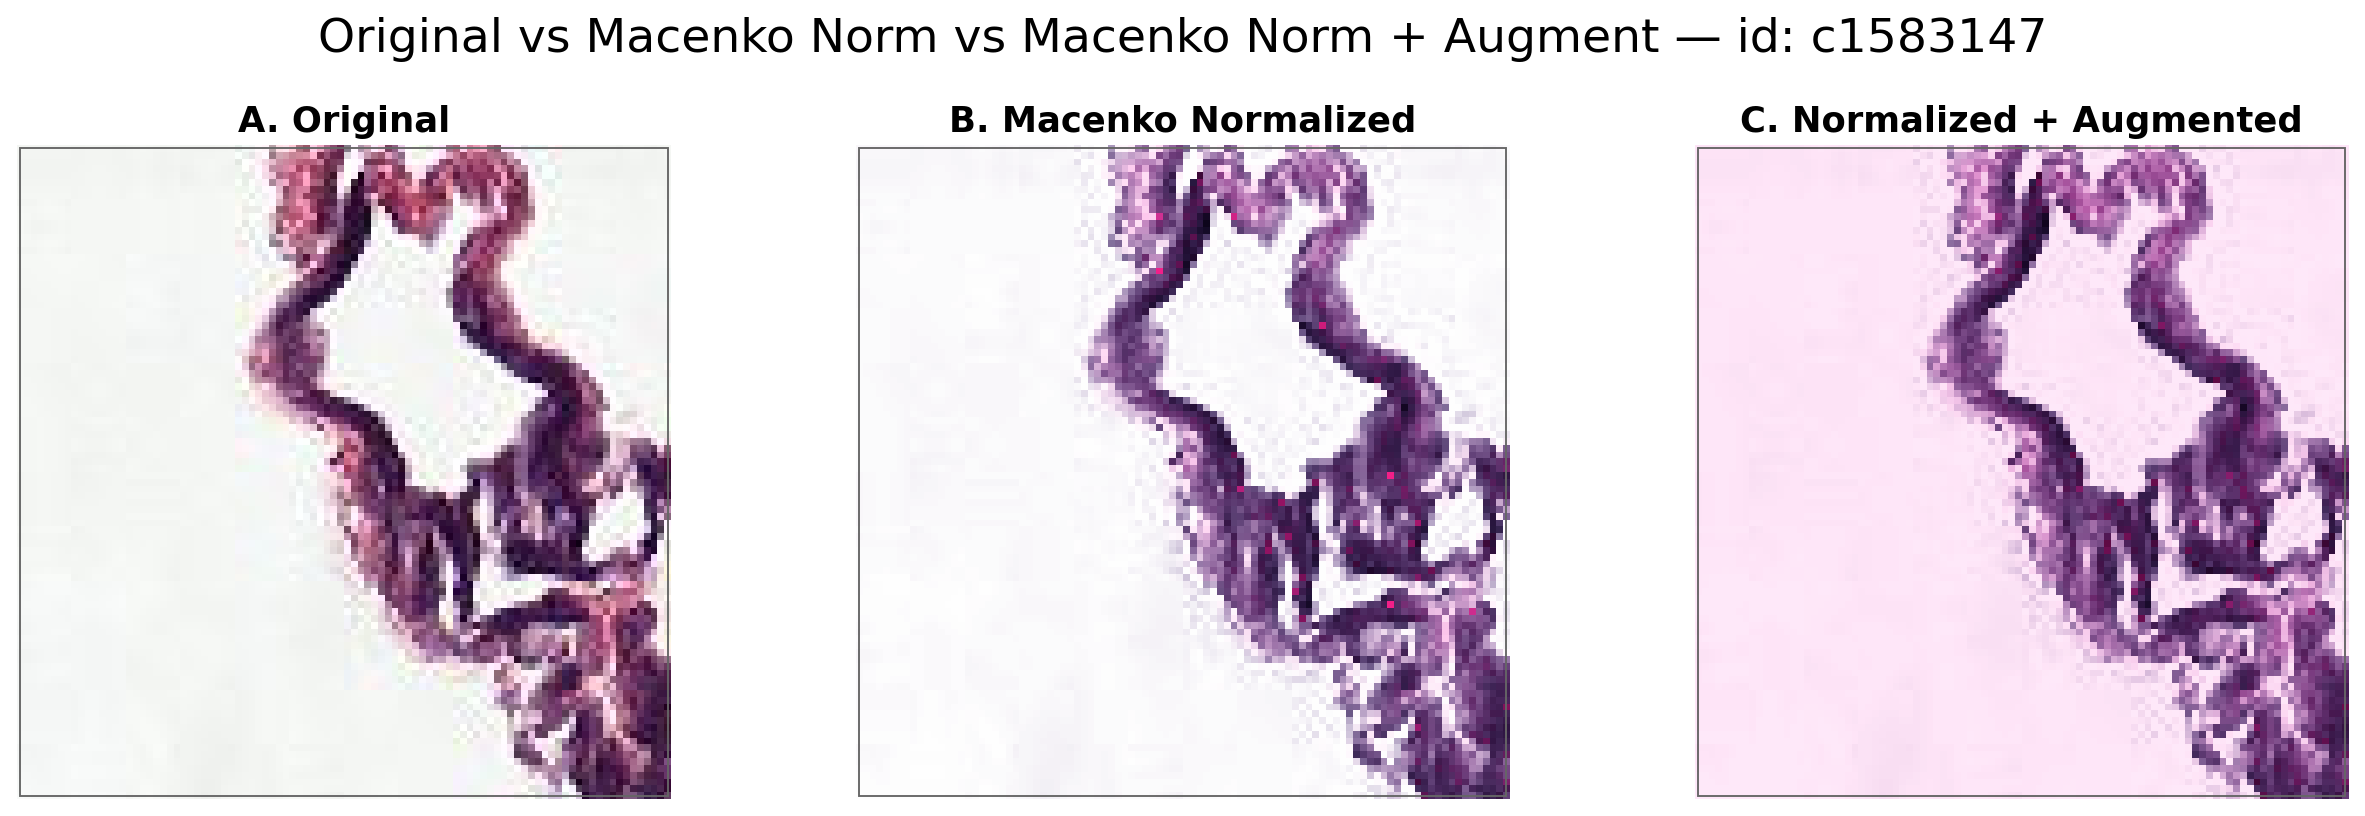

In [ ]:
from matplotlib.patches import Rectangle

# Grab .tif image paths from original (non-normalized) dataset
image_paths = glob.glob(os.path.join(train_path, "*.tif"))
num_samples = 10000
selected_paths = np.random.choice(image_paths, num_samples, replace=False)

# Select best reference image based on median color
color_means = [np.mean(read_image(p), axis=(0, 1)) for p in selected_paths]
median_color = np.median(color_means, axis=0)
closest_idx = np.argmin(np.linalg.norm(color_means - median_color, axis=1))
best_ref_path = selected_paths[closest_idx]
reference_image = read_image(best_ref_path)

# Pick a test image path from training set
random_test_path = np.random.choice(image_paths)
def show_stain_panel(orig, norm, aug, *, sample_id=None):
    # Global-ish style tweaks for this figure only
    plt.rcParams.update({
        "figure.dpi": 170,
        "font.size": 13,
        "axes.titlesize": 15,
        "axes.titleweight": "semibold",
        "figure.titlesize": 20,
    })

    # Wide but not huge; constrained layout handles spacing incl. suptitle
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), layout="constrained")

    supt = "Original vs Macenko Norm vs Macenko Norm + Augment"
    if sample_id:
        supt += f"- id: {str(sample_id)[:8]}"

    # Corrected line to fix the overlapping title
    fig.suptitle(supt, y=1)

    imgs = [orig, norm, aug]
    titles = ["A. Original", "B. Macenko Normalized", "C. Normalized + Augmented"]

    for ax, im, title in zip(axes, imgs, titles):
        ax.imshow(im, interpolation="nearest")  # keeps 96×96 tiles crisp
        ax.set_title(title, pad=6)
        ax.set_xticks([]); ax.set_yticks([])
        # subtle border around the image area
        h, w = im.shape[:2]
        ax.add_patch(Rectangle((0, 0), w-1, h-1, fill=False, lw=0.8, edgecolor="#666"))
        # remove spines (axes border)
        for spine in ax.spines.values(): spine.set_visible(False)
    plt.tight_layout()
    plt.show()

# test image (raw tif)
test_img = read_image(random_test_path)

# normalize
normalizer = StainNormalizer(method='macenko', luminosity_threshold=0.8, angular_percentile=99)
normalizer.fit(reference_image)
normalized_img = normalizer.transform(test_img)

# augment on the normalized image
augmentor = StainAugmentor(sigma1=0.2, sigma2=0.2, augment_background=True)
augmentor.fit(normalized_img)
augmented_img = augmentor.pop()

show_stain_panel(test_img, normalized_img, augmented_img, sample_id=os.path.basename(random_test_path).split('.')[0])

### .npy vs .tif
1. Faster I/O (Load Time)
 - .npy files are stored in a raw binary format, optimized for NumPy arrays.
 - Loading with np.load() is much faster than decoding .tif with cv2.imread() (which has to decode the image format).
 - This improves training throughput, especially with large datasets and high parallelism (num_workers, prefetch, etc.).

2. Zero Decoding Overhead
 - .tif files (especially 16-bit or multi-page ones) require parsing and decoding every time.
 - .npy is just memmap-friendly binary so you get an array instantly without needing to convert from disk format to tensor format.

3. Exact Pixel Fidelity
    When you save as .tif, you're typically saving in 8-bit or 16-bit format, which may, Compress pixel values, Clip float values, Lose precision (especially after Macenko normalization which returns float32). With .npy, you preserve the exact float32 output from normalization.

4. Simpler Data Pipelines
 - model expects input as a NumPy array or Tensor, so .npy is a direct drop-in.
 - No need to convert from BGR -> RGB, uint8 -> float32, etc. again.

In [ ]:
import json
from pathlib import Path

def apply_and_save_images(
    df,
    input_dir,
    output_dir,
    *,
    normalizer=None, # pass a pre-fit StainNormalizer OR
    reference_image=None, # provide this to fit internally (only if normalizer is None)
    normalize=True,
    augment=False,
    n_aug=1, # how many augmented versions per tile
    sigma1=0.2,
    sigma2=0.2,
    resize_to=(96, 96), # enforce training size
    compressed=True, # use .npz (compressed) or .npy
    seed=42
):
    """
    Save (optionally) normalized & augmented images as NumPy arrays.
    Writes <id>.npz (or .npy) and <id>_aug{k}.npz for augmentations.
    """
    rng = np.random.default_rng(seed)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Fit normalizer once if requested
    if normalize and normalizer is None:
        if reference_image is None:
            raise ValueError("normalize=True but neither `normalizer` nor `reference_image` provided.")
        normalizer = StainNormalizer(method='macenko', luminosity_threshold=0.8, angular_percentile=99)
        normalizer.fit(reference_image)

    # Write a small metadata file alongside the cache
    meta = {
        "normalize": bool(normalize),
        "augment": bool(augment),
        "n_aug": int(n_aug),
        "sigma1": float(sigma1),
        "sigma2": float(sigma2),
        "resize_to": list(resize_to) if resize_to else None,
        "compressed": bool(compressed),
        "stain_norm": "macenko" if normalize else None,
    }
    (output_dir / "_cache_meta.json").write_text(json.dumps(meta, indent=2))

    # Helper savers
    def _save(arr, path_no_ext):
        if compressed:
            np.savez_compressed(f"{path_no_ext}.npz", img=arr)
        else:
            np.save(f"{path_no_ext}.npy", arr)

    for img_id in tqdm(df["id"], desc=f"Saving → {output_dir.name}"):
        try:
            path = os.path.join(input_dir, img_id + ".tif")
            img = read_image(path)                           # RGB uint8

            # enforce size
            if resize_to and (img.shape[1], img.shape[0]) != (resize_to[0], resize_to[1]):
                img = cv2.resize(img, resize_to, interpolation=cv2.INTER_AREA)

            # optional normalization
            if normalize:
                img = normalizer.transform(img)              # RGB uint8

            # save normalized/original
            _save(img, str(output_dir / img_id))

            # optional augmentations (derived from the saved img)
            if augment and n_aug > 0:
                augmentor = StainAugmentor(sigma1=sigma1, sigma2=sigma2, augment_background=True)
                augmentor.fit(img)
                for k in range(n_aug):
                    aug = augmentor.pop()
                    # non-neg, correct dtype
                    aug = np.clip(aug, 0, 255).astype(np.uint8)
                    _save(aug, str(output_dir / f"{img_id}_aug{k}"))

        except Exception as e:
            # log & continue
            print(f"[WARN] {img_id}: {e}")
            continue

In [13]:
# Split train/val
train_ids, val_ids = train_test_split(train_labels_path['id'], test_size=0.2, stratify=train_labels_path['label'], random_state=100)
train_df = train_labels_path[train_labels_path['id'].isin(train_ids)]
val_df = train_labels_path[train_labels_path['id'].isin(val_ids)]

# 1) Fit once (recommended) and reuse across splits
normalizer = StainNormalizer(method='macenko', luminosity_threshold=0.8, angular_percentile=99)
normalizer.fit(reference_image)

# 2) Cache train/val/test
apply_and_save_images(
    train_df, train_path, "/workspace/data/macenko_train",
    normalizer=normalizer, normalize=True, augment=False, compressed=True
)

apply_and_save_images(
    val_df, train_path, "/workspace/data/macenko_val",
    normalizer=normalizer, normalize=True, augment=False, compressed=True
)

/tmp/ipykernel_27294/2359134986.py:14: RuntimeWarning: invalid value encountered in divide
  img_lab[:, :, 0] = np.clip(255 * L / p, 0, 255).astype(np.uint8)
/tmp/ipykernel_27294/2359134986.py:14: RuntimeWarning: invalid value encountered in cast
  img_lab[:, :, 0] = np.clip(255 * L / p, 0, 255).astype(np.uint8)
Saving → macenko_val: 100%|███████████████| 44005/44005 [18:00<00:00, 40.72it/s]


In [14]:
# Cache test images (no labels, just image IDs)
apply_and_save_images(
    pd.DataFrame({"id": [p[:-4] for p in os.listdir(test_path) if p.endswith(".tif")]}),
    test_path, "/workspace/data/macenko_test",
    normalizer=normalizer, normalize=True, augment=False, compressed=True
)

Saving → macenko_test: 100%|██████████████| 57458/57458 [19:59<00:00, 47.92it/s]


In [ ]:
train_path_macenko = '/workspace/data/macenko_train'
val_path_macenko   = '/workspace/data/macenko_val'
test_path_macenko  = '/workspace/data/macenko_test'

def read_cached_rgb(path):
    """
    Load RGB uint8 image from .npz (key 'img'), .npy (HWC uint8), or .tif.
    Returns uint8 HWC.
    """
    if path.endswith(".npz"):
        with np.load(path) as f:
            img = f["img"]
    elif path.endswith(".npy"):
        img = np.load(path)
    elif path.lower().endswith((".tif", ".tiff")):
        bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if bgr is None: 
            raise FileNotFoundError(path)
        img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    else:
        raise ValueError(f"Unsupported image type: {path}")
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)
    return img

### Image Preprocessing and Augmentation

To improve model robustness and focus on relevant tissue areas, I applied adapted augmentations from Joni Juvonen's public Kaggle Notebook (https://www.kaggle.com/code/qitvision/a-complete-ml-pipeline-fast-ai). Similarly, my model performed better when I did not crop my image as much. I orginally ran my model with crop size set to 32x32, since that is where the tumors are present if they are cancerous. However, my model did not perform nearly as well as when I performed minimal cropping. I also expanded on Joni's work to perform all of the following augmentations:

- Cropping: Reduced image size from 96x96 to 90x90 pixels to remove edge artifacts and allow small random shifts (+/- 3 pixels). 
- Rotation & Shifting: Random rotation (+/- 3°) and optional 90° turns to add variation. Random shifts gives the model different perspectives
- Flipping & Color Adjustments: Horizontal/vertical flips, hue shifts, and brightness/contrast adjustments to enhance generalization.
- Elastic Deformation: Simulates realistic tissue distortions using a smoothing factor (σ = 0.05 * crop_size)
- Gaussian Noise: Introduces slight noise (σ = 5) to improve model robustness

These augmentations help the model generalize better to unseen histology images.


In [13]:
# constants
original_size = 96 # DO NOT CHANGE
crop_size = 90 # final crop size

# augmentation parameters
random_rotation = 3 # degrees
random_shift = 3  # pixel shift for cropping
random_brightness = 0.1 # brightness adjustment (scaled to 0-1, converted to 0-255)
random_contrast = 0.1 # contrast adjustment
random_90_degree_turn = True # random 90 degree rotation

# elastic deformation 
alpha = 2.0 # scaling factor for deformation
sigma = 0.05 * crop_size # smoothing factor

# noise
noise_stddev = 5 # stdev of Gaussian noise

def read_cropped_image(path, augment=True, for_model=False):
    """
    If for_model=False -> returns float32 in [0,1] (nice for plotting).
    If for_model=True  -> returns float32 in [0,255] (to feed EfficientNetV2).
    """
    img = read_cached_rgb(path)  # uint8

    # ensure base size
    if img.shape[:2] != (original_size, original_size):
        img = cv2.resize(img, (original_size, original_size), interpolation=cv2.INTER_AREA)

    if not augment:
        start = (original_size - crop_size) // 2
        img = img[start:start+crop_size, start:start+crop_size]
        if for_model:
            return img.astype(np.float32)          # 0..255 float
        else:
            return (img.astype(np.float32) / 255.) # 0..1 float

    # geometric augments
    angle = random.randint(-random_rotation, random_rotation)
    if random_90_degree_turn:
        angle += random.choice([0, 90, -90, 180])
    M = cv2.getRotationMatrix2D((original_size // 2, original_size // 2), angle, 1.0)
    img = cv2.warpAffine(img, M, (original_size, original_size), borderMode=cv2.BORDER_REFLECT_101)

    x_shift = random.randint(-random_shift, random_shift)
    y_shift = random.randint(-random_shift, random_shift)
    start = (original_size - crop_size) // 2
    img = img[start + y_shift:start + y_shift + crop_size,
              start + x_shift:start + x_shift + crop_size]

    # flips
    if random.random() < 0.5: img = cv2.flip(img, 1)
    if random.random() < 0.2: img = cv2.flip(img, 0)

    # light HSV jitter (uint8 in, uint8 out)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hue_shift = random.randint(-5, 5)
    hsv[..., 0] = np.clip(hsv[..., 0].astype(np.int16) + hue_shift, 0, 179).astype(np.uint8)
    img = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

    # elastic
    dx = cv2.GaussianBlur((np.random.rand(*img.shape[:2]) * 2 - 1), (17, 17), sigma) * alpha
    dy = cv2.GaussianBlur((np.random.rand(*img.shape[:2]) * 2 - 1), (17, 17), sigma) * alpha
    x, y = np.meshgrid(np.arange(img.shape[1]), np.arange(img.shape[0]))
    img = cv2.remap(img, (x + dx).astype(np.float32), (y + dy).astype(np.float32),
                    interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

    # brightness/contrast + noise (float domain)
    img = img.astype(np.float32)
    brightness = random.uniform(-random_brightness, random_brightness) * 255.0
    contrast   = random.uniform(1.0 - random_contrast, 1.0 + random_contrast)
    img = np.clip(contrast * img + brightness, 0, 255)
    noise_stddev_scaled = max(noise_stddev, 0.05 * float(np.mean(img)))
    img = np.clip(img + np.random.normal(0, noise_stddev_scaled, img.shape).astype(np.float32), 0, 255)

    if for_model:
        return img  # float32 0..255
    else:
        return (img / 255.).astype(np.float32)  # float32 0..1


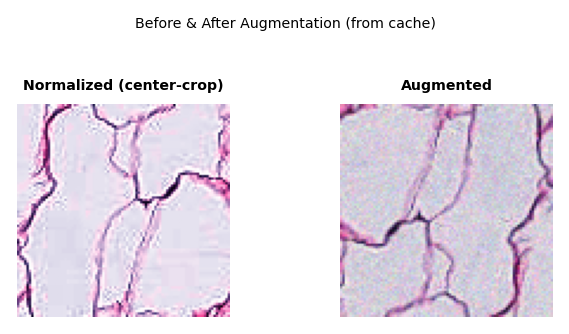

In [14]:
# pick an actually cached .npz 
cached_files = [f for f in os.listdir(train_path_macenko) if f.endswith(".npz")]
assert cached_files, "No cached .npz files found in train_path_macenko."

random_sample = np.random.choice(cached_files)
sample_path = os.path.join(train_path_macenko, random_sample)

fig, ax = plt.subplots(1, 2, figsize=(4, 2))
fig.suptitle('Before & After Augmentation (from cache)', fontsize=6)

ax[0].imshow(read_cropped_image(sample_path, augment=False))
ax[0].set_title('Normalized (center-crop)', fontsize=6); ax[0].axis('off')

ax[1].imshow(read_cropped_image(sample_path, augment=True))
ax[1].set_title('Augmented', fontsize=6); ax[1].axis('off')

plt.tight_layout(); plt.show()


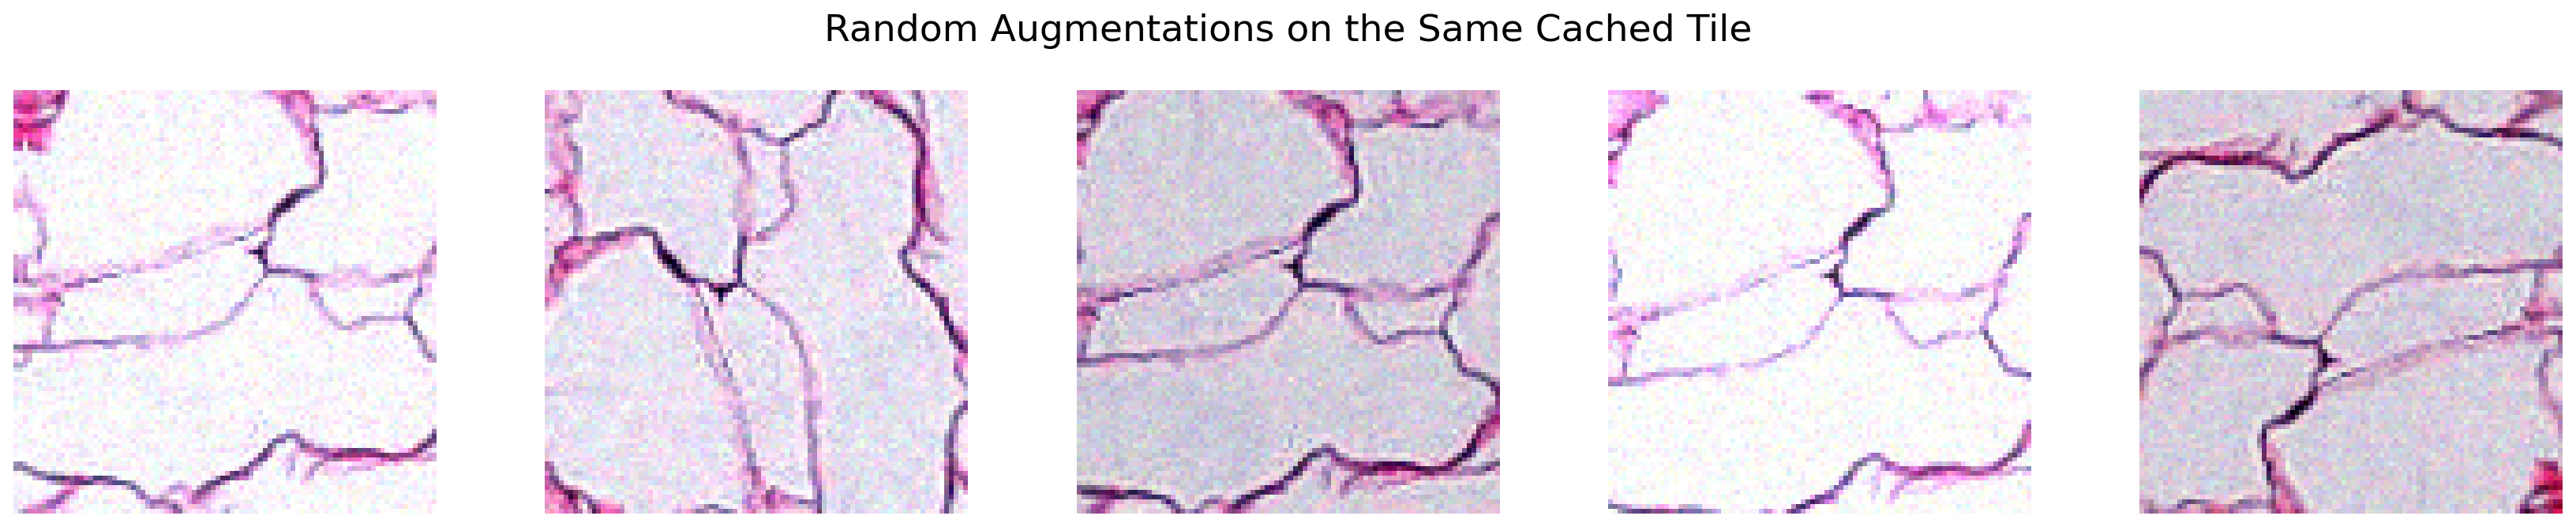

In [15]:
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Random Augmentations on the Same Cached Tile', fontsize=20)

for i in range(5):
    ax[i].imshow(read_cropped_image(sample_path, augment=True))
    ax[i].axis('off')

plt.tight_layout(); plt.show()

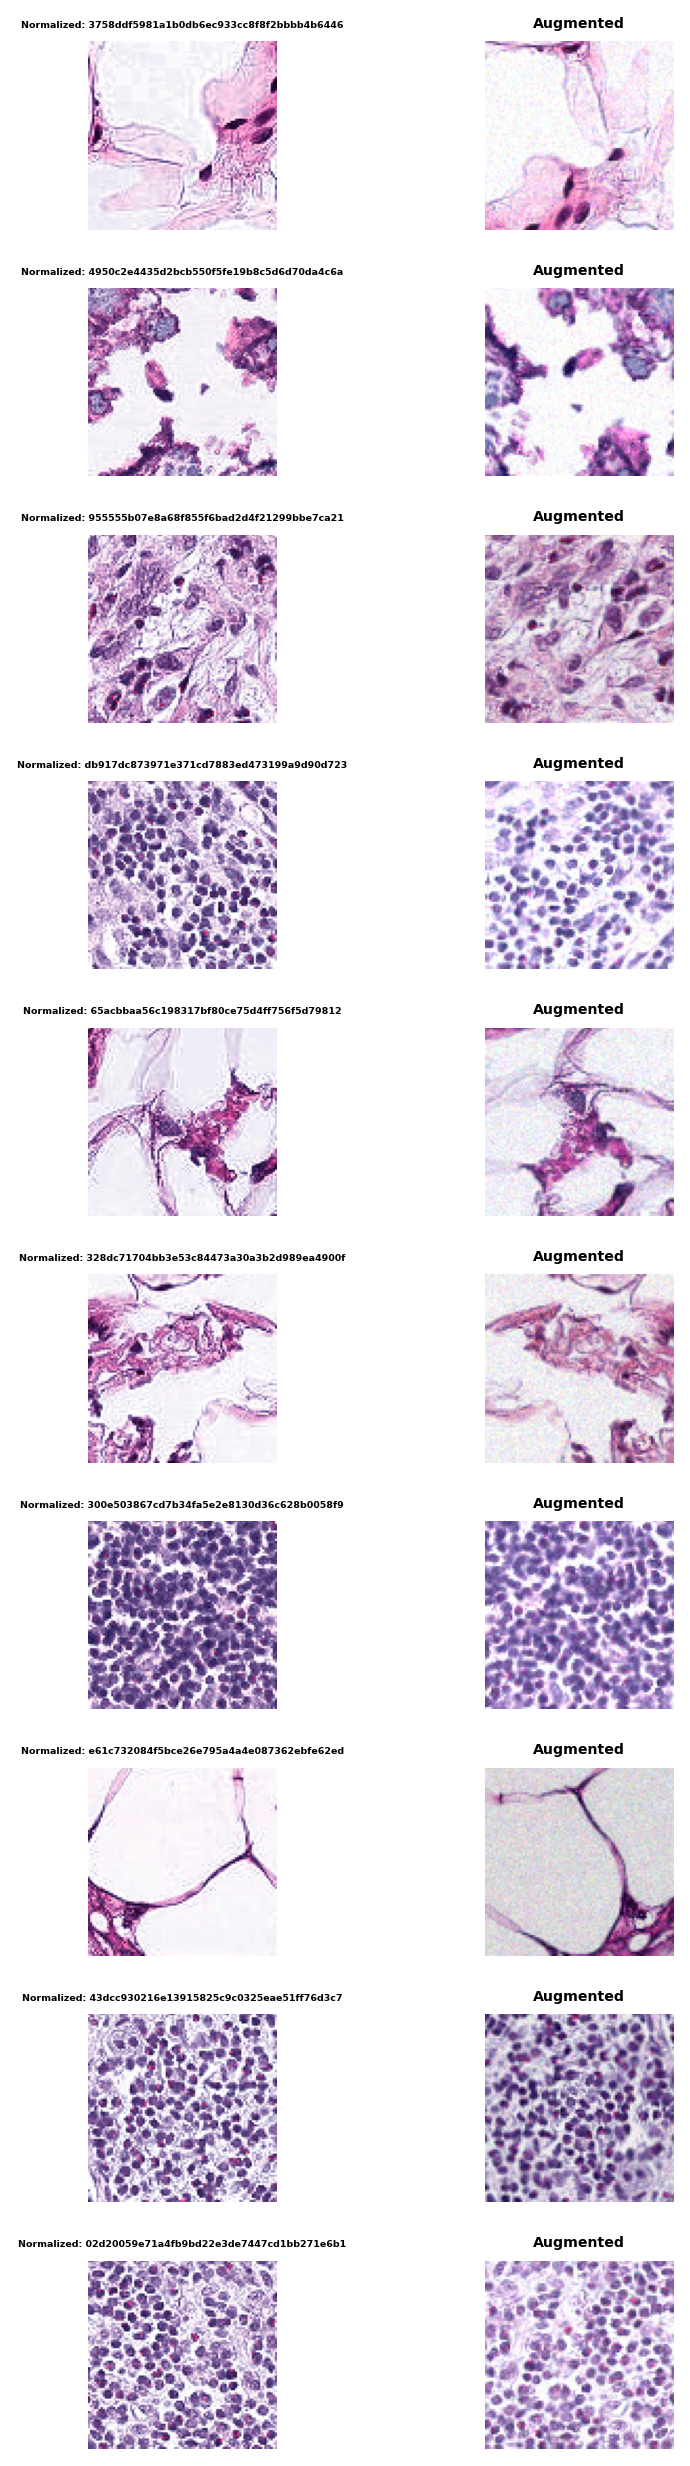

In [16]:
available_ids = [os.path.splitext(f)[0] for f in os.listdir(train_path_macenko) if f.endswith(".npz")]
random_sample_ids = np.random.choice(available_ids, size=min(10, len(available_ids)), replace=False)

fig, axes = plt.subplots(len(random_sample_ids), 2, figsize=(6, 1.5*len(random_sample_ids)))
if len(random_sample_ids) == 1:
    axes = np.array([axes])  # ensure 2D indexable

for i, sid in enumerate(random_sample_ids):
    p = os.path.join(train_path_macenko, f"{sid}.npz")
    original_img  = read_cropped_image(p, augment=False)
    augmented_img = read_cropped_image(p, augment=True)

    axes[i, 0].imshow(original_img);  axes[i, 0].set_title(f"Normalized: {sid}", fontsize=4); axes[i, 0].axis("off")
    axes[i, 1].imshow(augmented_img); axes[i, 1].set_title("Augmented", fontsize=6);         axes[i, 1].axis("off")

plt.tight_layout(rect=[0, 0, 1, .98]); plt.show()

### Statistics

Image statistics like channel mean, standard deviation, and brightness help me make normalization choices. This dataset has a higher mean than ImageNet, but since I’m fine-tuning EfficientNet, I used ImageNet’s mean & std. The standard deviation was similar to ImageNet, indicating no major contrast issues.  

Stats also help detect problematic images like extremely dark image (possibly corrupted) and overly bright ones (potential overexposure). I may remove them if they impact training. When I first ran my stats code I had detected one extremely dark image and 12 overly exposed image. After applying stain normalization, no images were extremely dark or bright. 


In [17]:
from concurrent.futures import ThreadPoolExecutor

dark_threshold   = 10 / 255
bright_threshold = 245 / 255

cached_paths = [os.path.join(train_path_macenko, f) for f in os.listdir(train_path_macenko) if f.endswith(".npz")]
assert cached_paths, "No cached .npz files found."

def process_path(npz_path):
    try:
        img = read_cropped_image(npz_path, augment=False)  # float32 [0,1], 90x90x3
    except Exception as e:
        return {"status": "error", "id": os.path.basename(npz_path), "err": str(e)}

    flat = img.reshape(-1, 3)
    if flat.max() < dark_threshold:
        return {"status": "too_dark", "id": os.path.basename(npz_path)}
    if flat.min() > bright_threshold:
        return {"status": "too_bright", "id": os.path.basename(npz_path)}

    return {
        "status": "normal",
        "id": os.path.basename(npz_path),
        "mean": flat.mean(axis=0),
        "squared_mean": (flat**2).mean(axis=0),
    }

results = []
with ThreadPoolExecutor() as ex:
    for res in tqdm(ex.map(process_path, cached_paths), total=len(cached_paths), desc="Computing statistics"):
        results.append(res)

x_tot = np.zeros(3); x2_tot = np.zeros(3); counted = 0
too_dark, too_bright = [], []

for r in results:
    if r["status"] == "normal":
        x_tot += r["mean"]; x2_tot += r["squared_mean"]; counted += 1
    elif r["status"] == "too_dark":   too_dark.append(r["id"])
    elif r["status"] == "too_bright": too_bright.append(r["id"])

channel_mean = x_tot / max(counted, 1)
channel_std  = np.sqrt(x2_tot / max(counted, 1) - channel_mean**2)

image_statistics = {
    "Channel Mean": channel_mean.tolist(),
    "Channel Std": channel_std.tolist(),
    "Total Images Processed": counted,
    "Extremely Dark Images": len(too_dark),
    "Extremely Bright Images": len(too_bright),
    "First 5 Dark Image IDs": too_dark[:5],
    "First 5 Bright Image IDs": too_bright[:5],
}
image_statistics

Computing statistics: 100%|████████████| 176020/176020 [03:29<00:00, 841.18it/s]


{'Channel Mean': [0.7431216980908437, 0.6006913147197082, 0.75714636065842],
 'Channel Std': [0.24679383397921673, 0.27956191917242373, 0.1951051321370868],
 'Total Images Processed': 176016,
 'Extremely Dark Images': 0,
 'Extremely Bright Images': 4,
 'First 5 Dark Image IDs': [],
 'First 5 Bright Image IDs': ['03e9e1cfd68e80e5f5b7e1b67a8db23c44f95f4e.npz',
  '16d32f03c77279d0f13526a0d8541b7064052809.npz',
  '54df3640d17119486e5c5f98019d2a92736feabc.npz',
  '9369c7278ec8bcc6c880d99194de09fc2bd4efbe.npz']}

### ImageNet Normalization and TensorFlow Pipeline

EfficientNetV2 expects zero-centered normalization: **img = (img - imagenet_mean) / imagenet_std**, aligns pixel values with ImageNet stats for better performance. The initial **/ 255.0** scaling makes values interpretable, while ImageNet normalization provides model compatibility.  

I use ImageNet mean ([0.485, 0.456, 0.406]) and std ([0.229, 0.224, 0.225]) to match the pretrained EfficientNetV2 and ViT-Hybrid models, maintaining consistency for effective transfer learning.  

In [25]:
# ImageNet normalization (expects img in [0,1])
imagenet_mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
imagenet_std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def normalize_image_for_efficientnet(img_f01: np.ndarray) -> np.ndarray:
    # img_f01: float32 in [0,1], shape [crop_size, crop_size, 3]
    return ((img_f01 - imagenet_mean) / imagenet_std).astype(np.float32)

# Python-side loader used inside tf.py_function 
def _py_load_and_preprocess_cached(path_tensor, ds_type: str):
    """
    path_tensor: tf.Tensor scalar (tf.string) path to .npz/.npy/.tif
    ds_type: "train" or "val" (plain Python string)
    Returns: float32 [crop_size, crop_size, 3], ImageNet-normalized
    """
    # Tensor -> python string
    p = path_tensor.numpy().decode("utf-8")
    # your cached reader (returns uint8 HxWx3), then augment+crop -> float32 [0,1]
    img_f01 = read_cropped_image(p, augment=(ds_type == "train")) # float32 [0..1], (crop_size, crop_size, 3)
    return normalize_image_for_efficientnet(img_f01) # float32

# Single dataset builder (cached) 
def build_tf_dataset_cached(image_paths, labels, batch_size=128, shuffle=True, dataset_type="train"):
    """
    image_paths: list/np.array of .npz paths (preferred), or .npy/.tif (read_cached_rgb handles it)
    labels:     list/np.array of 0/1 floats (or ints)
    """
    paths_tf = tf.convert_to_tensor(image_paths, dtype=tf.string)
    labels_tf = tf.convert_to_tensor(labels, dtype=tf.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths_tf, labels_tf))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(image_paths), 10000), reshuffle_each_iteration=True)

    def _map_fn(path_tensor, y):
        img_f32 = tf.py_function(
            func=lambda q: _py_load_and_preprocess_cached(q, dataset_type),
            inp=[path_tensor],
            Tout=tf.float32,   # returns float32
        )
        img_f32.set_shape([crop_size, crop_size, 3]) # important for static shape
        # Cast images to float16 for mixed precision; keep labels float32 for metrics (AUC)
        return tf.cast(img_f32, tf.float16), tf.cast(y, tf.float32)

    ds = ds.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.622571].


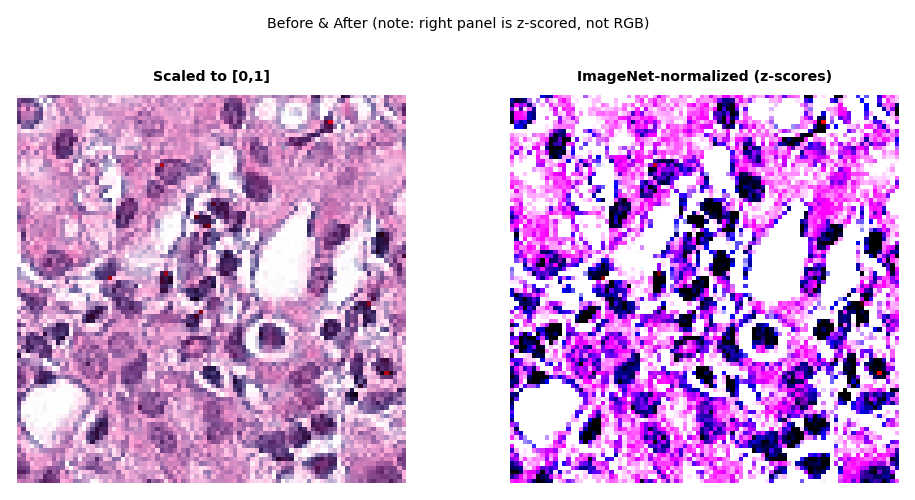

In [26]:
# select random sample that actually exists in the cache
sample_id = os.path.splitext(os.listdir(train_path_macenko)[0])[0]  # quick pick
sample_path = os.path.join(train_path_macenko, sample_id + '.npz')

# test preprocessing
original_image  = read_cropped_image(sample_path, augment=False)          # [0,1]
normalized_image = normalize_image_for_efficientnet(original_image)       # z-scored

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
fig.suptitle('Before & After (note: right panel is z-scored, not RGB)', fontsize=6)

ax[0].imshow(original_image)
ax[0].set_title('Scaled to [0,1]', fontsize=6); ax[0].axis('off')

# imshow on z-scores = not visually meaningful (but OK if you just want a check)
ax[1].imshow(normalized_image)  
ax[1].set_title('ImageNet-normalized (z-scores)', fontsize=6); ax[1].axis('off')
plt.tight_layout(); plt.show()

### Removing the Bright and Dark Images before Training

In [27]:
bad_ids = set(too_dark) | set(too_bright)
filtered_train_labels = train_labels_path[~train_labels_path['id'].isin(bad_ids)].copy()
print(f"Original dataset size: {len(train_labels_path)}")
print(f"Filtered dataset size: {len(filtered_train_labels)}")

Original dataset size: 220025
Filtered dataset size: 220025


### Train Test Split (80/20) with Stratification

In [28]:
from sklearn.model_selection import train_test_split

train_ids, val_ids = train_test_split(
    filtered_train_labels['id'],
    test_size=0.2,
    stratify=filtered_train_labels['label'],
    random_state=100
)

train_df = filtered_train_labels[filtered_train_labels['id'].isin(train_ids)].copy()
val_df   = filtered_train_labels[filtered_train_labels['id'].isin(val_ids)].copy()

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")


Training set size: 176020
Validation set size: 44005


### Checking Training and Validation Set Class Balance
No major class imbalances were seen when plotting the training set and validation set label counts. 

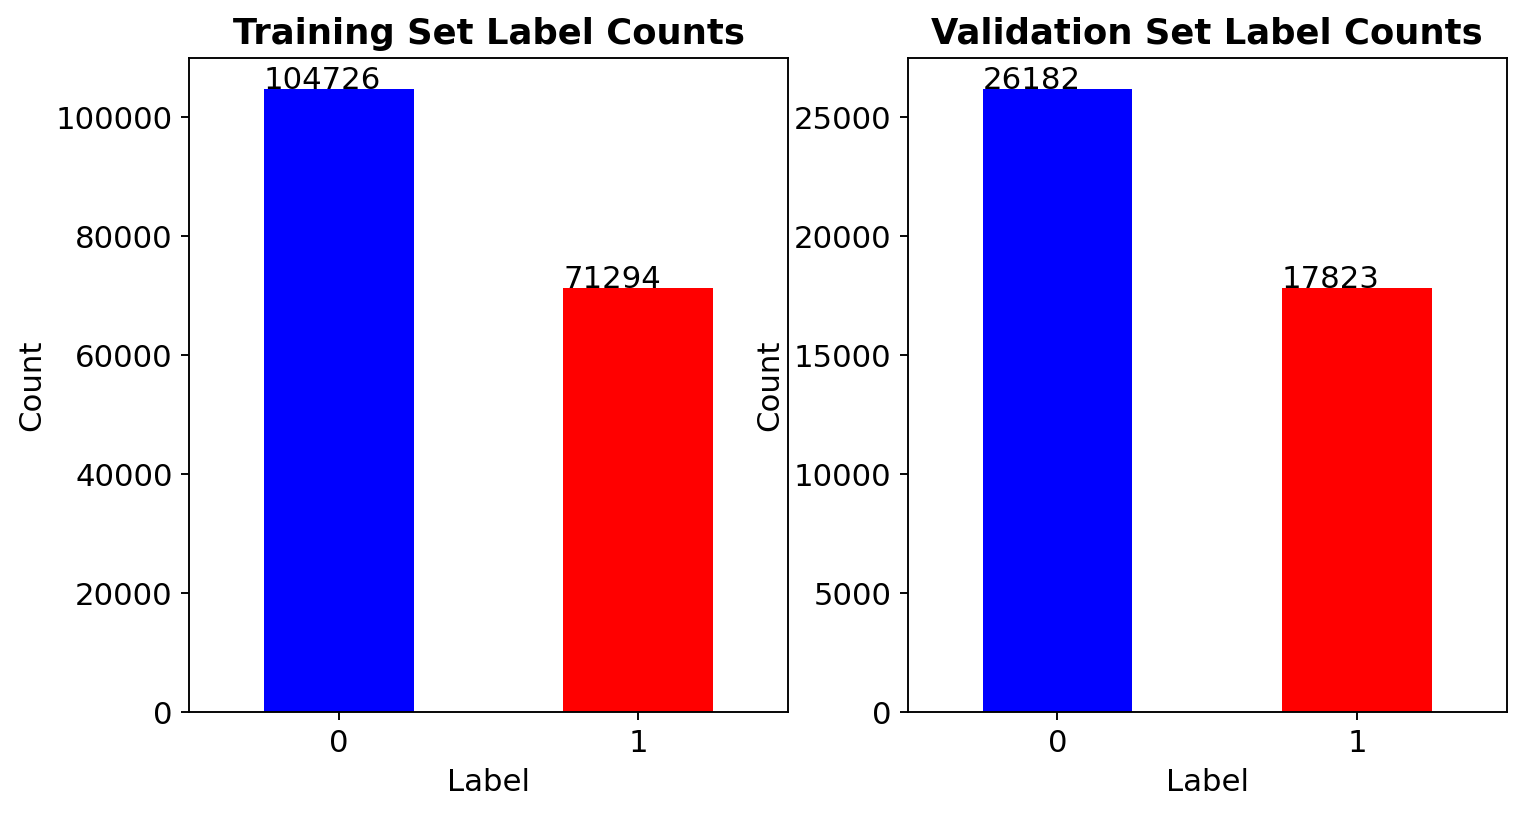

In [29]:
# get the counts
train_counts = train_df['label'].value_counts()
val_counts = val_df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 5)) 

train_counts.plot(kind='bar', ax=axes[0], color=['blue', 'red'])
axes[0].set_title('Training Set Label Counts')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['0', '1'], rotation=0) 
for p in axes[0].patches:
    axes[0].annotate(str(p.get_height()), (p.get_x(), p.get_height()))


val_counts.plot(kind='bar', ax=axes[1], color=['blue', 'red']) 
axes[1].set_title('Validation Set Label Counts')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['0', '1'], rotation=0) 
for p in axes[1].patches: 
    axes[1].annotate(str(p.get_height()), (p.get_x(), p.get_height()))

plt.show()

# Model Architecture Strategy and Training  

EfficientNetV2s is a CNN, so it excels at local feature extraction (textures, edges), while Vision Transformer models capture global dependencies. Given the dataset size (176k train, 44k val) and the fact that histology slides have fine grained patterns in cell structures and broader contextual information like tissue organization I decided to use EfficientNetV2S as my baseline model and vision transformer hybrid model.
EfficientNetV2S is optimized for CNN-based feature extraction, using transfer learning with a lightweight classification head (128 → 1).
My ViT-Hybrid model will then use EfficientNetV2S as a backbone while including transformer-based multi-head attention layers, allowing it to capture both fine and high-level features.

### Training EfficientNetV2S with One-Cycle Policy

One-Cycle Learning Rate (LR) Policy is a way to dynamically adjust the learning rate instead of keeping it constant, leading to faster convergence and reduced overfitting. This approach involves:  

Warm-up phase: LR gradually increases to a peak value.  
Decay phase: LR smoothly decreases for better convergence.  
Momentum scheduling: Inversely adjusted to stabilize training.  

*Sources:* 

*[Tan, M., & Le, Q. V., 2021](https://arxiv.org/pdf/2104.00298)*

*[Leslie N. Smith, 2018](https://arxiv.org/pdf/1803.09820)*  

*[Leslie N. Smith, 2017](https://arxiv.org/pdf/1506.01186)*

#### EfficientNetV2S Training Pipeline
1. Learning Rate & Hyperparameter Optimization

 - Load a pretrained EfficientNetV2S model (ImageNet weights)
 - Run an LR range test with all layers trainable to determine the optimal learning rate
 - Use Optuna to tune weight decay (prevents overfitting) and dropout rate (reduces over-reliance on specific features)
 - Since hyperparameter tuning is computationally expensive, I used only 25% of the training and validation data for faster optimization

2. Feature Extraction (Transfer Learning)

 - Reload the pretrained EfficientNetV2S model with optimized hyperparameters
 - Freeze all convolutional layers to retain ImageNet-learned features
 - Train only the classification head (128 → 1 dense layers) to adapt the model to the new dataset

3. Fine-Tuning

 - Unfreeze all layers and train the full model
 - Use mixed precision training for efficiency and faster convergence
 - Apply One-Cycle Policy to dynamically adjust learning rate and momentum for stable training

Final Model Training Setup:

Batch Size: 128

Base LR: 0.0015 → Peak LR: 0.0045

Momentum Range: 0.9 → 0.95

Step Size: 2 × iterations per epoch (for full One-Cycle schedule)

### Learning Rate Range Test

In [ ]:
from tensorflow.keras.applications import EfficientNetV2S
# from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2S, preprocess_input

# Build file lists aligned with cache (.npz) 
train_id2label = dict(zip(train_df['id'].values, train_df['label'].values))
val_id2label = dict(zip(val_df['id'].values,   val_df['label'].values))

def make_cached_pairs(id2label, cache_dir):
    pairs = []
    for _id, y in id2label.items():
        p = os.path.join(cache_dir, f"{_id}.npz")
        if os.path.exists(p):
            pairs.append((p, y))
    return pairs

train_pairs = make_cached_pairs(train_id2label, train_path_macenko)
val_pairs = make_cached_pairs(val_id2label,   val_path_macenko)

assert len(train_pairs) > 0, "No cached training files found (.npz)."
assert len(val_pairs) > 0, "No cached validation files found (.npz)."

train_paths_list, train_labels_list = zip(*train_pairs)
val_paths_list, val_labels_list   = zip(*val_pairs)

train_paths_np = np.array(train_paths_list)
train_labels_np = np.array(train_labels_list, dtype=np.float32)
val_paths_np = np.array(val_paths_list)
val_labels_np = np.array(val_labels_list, dtype=np.float32)

# Build TF datasets 
batch_size = 128
train_ds = build_tf_dataset_cached(train_paths_np, train_labels_np, batch_size=batch_size, shuffle=True, dataset_type='train').repeat().prefetch(tf.data.AUTOTUNE)
val_ds = build_tf_dataset_cached(val_paths_np, val_labels_np, batch_size=batch_size, shuffle=False, dataset_type='val').cache().prefetch(tf.data.AUTOTUNE)

policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

# Model 
base_model = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(crop_size, crop_size, 3))
x = GlobalAveragePooling2D(dtype="float16")(base_model.output)
x = Dense(128, activation='gelu', dtype="float16")(x)
x = Dropout(0.2)(x)
x = Dense(1, activation='sigmoid', dtype="float32")(x)  # stable final dtype

# Make all layers trainable for LR test
for layer in base_model.layers:
    layer.trainable = True

# Stepsize for LR range test: use actual #batches from cached set 
iterations_per_epoch = max(1, len(train_paths_np) // batch_size)
stepsize = max(10, 2 * iterations_per_epoch) # to make sure it's not too tiny
print(f"Computed stepsize for LR range test: {stepsize} (iters/epoch={iterations_per_epoch})")

# LR Finder callback (set learning_rate, not lr) 
class LRFinder(tf.keras.callbacks.Callback):
    def __init__(self, min_lr=1e-6, max_lr=0.5, steps=stepsize, validation_data=None):
        super().__init__()
        self.min_lr = float(min_lr)
        self.max_lr = float(max_lr)
        self.steps = int(steps)
        self.history = []
        self.best_loss = float('inf')
        self.validation_data = validation_data
        self.lr = None

    def on_batch_begin(self, batch, logs=None):
        if batch == 0 or self.lr is None:
            self.lr = self.min_lr
        else:
            self.lr *= (self.max_lr / self.min_lr) ** (1.0 / self.steps)
        tf.keras.backend.set_value(self.model.optimizer.learning_rate, self.lr)

    def on_batch_end(self, batch, logs=None):
        train_loss = logs.get("loss", None)
        val_loss, val_acc = None, None
        if self.validation_data and (batch % 10 == 0):
            # returns (loss, accuracy, auc) — we take first two
            ev = self.model.evaluate(self.validation_data, verbose=0)
            val_loss = ev[0]
            val_acc  = ev[1] if len(ev) > 1 else None

        self.history.append((self.lr, train_loss, val_loss, val_acc))

        if train_loss is not None:
            if train_loss < self.best_loss: self.best_loss = train_loss
            if train_loss > self.best_loss * 10:  # early stop on divergence
                self.model.stop_training = True

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs["lr"] = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))

# Optimizer & compile 
optimizer = LossScaleOptimizer(SGD(learning_rate=1e-6, momentum=0.95))
model = Model(inputs=base_model.input, outputs=x)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', AUC(name='auc')])

# Run LR range test
lr_finder = LRFinder(min_lr=1e-6, max_lr=0.01, steps=stepsize, validation_data=val_ds)
history = model.fit(train_ds, validation_data=val_ds, epochs=1, steps_per_epoch=stepsize, callbacks=[lr_finder])

Computed stepsize for LR range test: 2750 (iters/epoch=1375)


2025-08-27 23:36:49.825260: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 2999 of 10000
2025-08-27 23:36:59.825358: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 5931 of 10000
2025-08-27 23:37:09.830698: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 8847 of 10000
2025-08-27 23:37:13.788590: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] Shuffle buffer filled.


1376/2750 [==============>...............] - ETA: 24:21 - loss: 0.6414 - accuracy: 0.6478 - auc: 0.6736

2025-08-28 00:03:39.515311: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 3035 of 10000
2025-08-28 00:03:49.509345: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 6059 of 10000
2025-08-28 00:03:59.505327: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 9151 of 10000
2025-08-28 00:04:02.498428: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] Shuffle buffer filled.


2750/2750 [==============================] - ETA: 0s - loss: 0.7489 - accuracy: 0.6869 - auc: 0.8544   

2025-08-28 00:28:21.492900: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] Filling up shuffle buffer (this may take a while): 1380 of 10000


2750/2750 [==============================] - 3122s 1s/step - loss: 0.7489 - accuracy: 0.6869 - auc: 0.8544 - val_loss: 0.6934 - val_accuracy: 0.6851 - val_auc: 0.8587 - lr: 0.0100


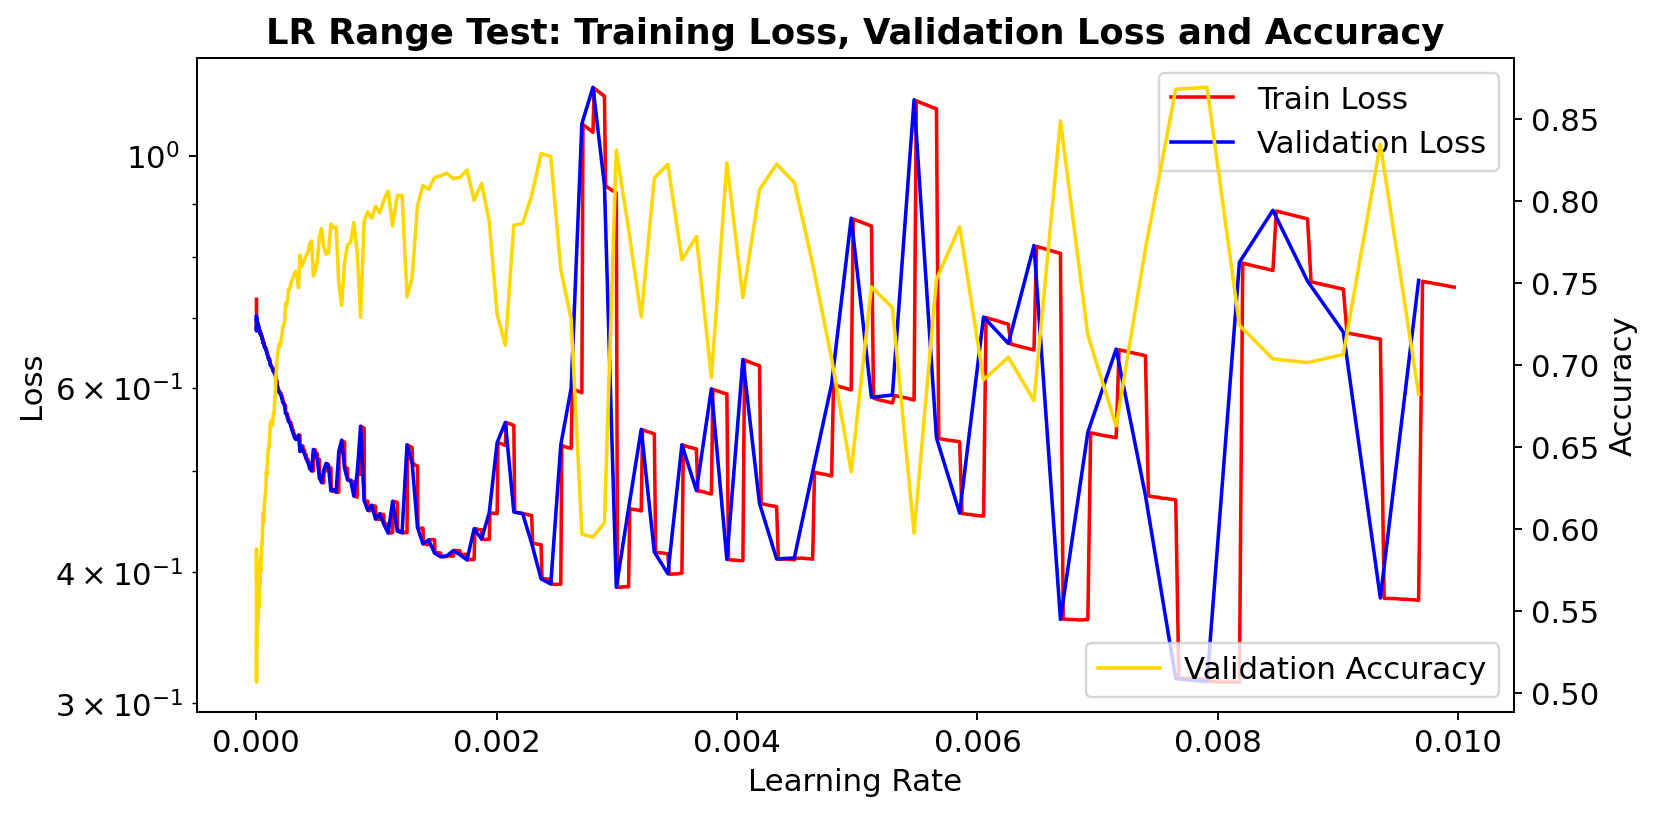

In [78]:
# store lr range test results
learning_rates, train_losses, val_losses, val_accs = zip(*lr_finder.history)

# convert lists to arrays for easy filtering
learning_rates = np.array(learning_rates)
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)
val_accs = np.array(val_accs)
    
# remove None/NaN values from val metrics
valid_indices = np.where(val_losses != None)[0] 
valid_lrs = learning_rates[valid_indices]
valid_val_losses = val_losses[valid_indices]
valid_val_accs = val_accs[valid_indices]

fig, ax1 = plt.subplots(figsize=(10,5))
# plot train loss
ax1.plot(learning_rates, train_losses, label="Train Loss", color="red")
# plot val loss for valid points only
ax1.plot(valid_lrs, valid_val_losses, label="Validation Loss", color="blue")
    
ax1.set_xscale("linear") # keep x-axis linear 
ax1.set_yscale("log") # log for loss
ax1.set_xlabel("Learning Rate")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
    
# second y-axis for accuracy
ax2 = ax1.twinx()
ax2.plot(valid_lrs, valid_val_accs, label="Validation Accuracy", color="gold")
ax2.set_ylabel("Accuracy")
ax2.legend(loc="lower right")
plt.title(f"LR Range Test: Training Loss, Validation Loss and Accuracy")
plt.show()

### LR Range Test Insights:
Training & Validation Losses (Red & Blue Lines)
 - Loss decreases steadily until ~0.0020
 - After ~0.0050, the loss is too high as it starts fluctuating and becomes unstable, as seen in the sharp increase

Validation Accuracy (Yellow Line)
 - Initially increases and stabilizes up to ~0.0017
 - Becomes unstable at > ~0.005

Best One-Cycle LR Values:
 - Base Learning Rate (base_lr) → 0.0010 - 0.0017 (safe low region)
 - Max Learning Rate (max_lr) → 0.0025 - 0.0040 (before instability kicks in)

### Tuning Weigth Decay and Dropout
I chose to use 0.003 for my fixed LR here because its between the base_lr and max_lr. Too low of a fixed LR will not give me any meaningful results, while too high of a LR could introduce instability. Therefore, 0.003 will be stable and allow WD and dropout impact to be visible without over regularization. 

In [ ]:
# Create reduced datasets ONCE (from cached, normalized .npz)
train_sample = train_df.sample(frac=0.25, random_state=100).reset_index(drop=True)
val_sample   = val_df.sample(frac=0.25, random_state=100).reset_index(drop=True)

train_paths_sub = [os.path.join(train_path_macenko, f"{i}.npz") for i in train_sample["id"]]
val_paths_sub   = [os.path.join(val_path_macenko, f"{i}.npz") for i in val_sample["id"]]

train_ds_subset = build_tf_dataset_cached(train_paths_sub, train_sample["label"].values, batch_size=128, shuffle=True,  dataset_type='train').prefetch(tf.data.AUTOTUNE)
val_ds_subset   = build_tf_dataset_cached(val_paths_sub, val_sample["label"].values, batch_size=128, shuffle=False, dataset_type='val').cache().prefetch(tf.data.AUTOTUNE)

def objective(trial, train_ds, val_ds):
    wd = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5, step=0.05)

    base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(crop_size, crop_size, 3))
    x = GlobalAveragePooling2D(dtype="float16")(base.output)
    x = Dense(128, activation='gelu', dtype="float16")(x)
    x = Dropout(dropout)(x)
    out = Dense(1, activation='sigmoid', dtype="float32")(x)

    opt = tf.keras.optimizers.SGD(learning_rate=0.003, momentum=0.95, weight_decay=wd, nesterov=True)
    opt = tf.keras.mixed_precision.LossScaleOptimizer(opt, dynamic=True)

    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy', AUC(name='auc')])

    steps = max(1, len(train_paths_sub) // 128)
    hist = model.fit(train_ds, validation_data=val_ds, epochs=1, steps_per_epoch=steps, verbose=0)
    return hist.history["val_loss"][-1]

study = optuna.create_study(direction="minimize")
study.optimize(lambda t: objective(t, train_ds_subset, val_ds_subset), n_trials=30)

best_params = study.best_params
print(f"Best weight decay: {best_params['weight_decay']}")
print(f"Best dropout: {best_params['dropout']}")

### One-Cycle Policy: Learning Rate & Momentum Scheduling

For total epochs = N, the learning rate follows a cyclical pattern to improve convergence:

### Learning Rate Schedule
- Phase 1: LR Increase:  
  $$
  LR = LR_{\text{min}} + (LR_{\text{max}} - LR_{\text{min}}) \times \frac{\text{epoch}}{N/2}
  $$

- Phase 2: LR Decrease:  
  $$
  LR = LR_{\text{max}} - (LR_{\text{max}} - LR_{\text{min}}) \times \frac{\text{epoch} - N/2}{N/2}
  $$

- Momentum: High when LR is low, low when LR is high.


### Cyclical Momentum Schedule
To stabilize training, **momentum is adjusted inversely** to the learning rate:

$$
\text{Momentum} = M_{\text{base}} + (M_{\text{max}} - M_{\text{base}}) \times \frac{1 - |x|}{2^{\text{cycle}}}
$$

where:
$$
x = \frac{\text{iteration}}{\text{step size}} - 2 \cdot \text{cycle} + 1 \quad \text{(cycle progress)}
$$

$$
\text{cycle} = \left\lfloor 1 + \frac{\text{iteration}}{2 \cdot \text{step size}} \right\rfloor \quad \text{(current cycle index)}
$$
At the start of training, momentum is high to dampen oscillations. N LR is low to prevent drastic updates. As training progresses momentum decreases while LR increases, encouraging exploration. At peak LR, momentum is at its lowest, allowing large updates. During the second half, momentum increases again while LR decreases, leading to smooth convergence.



## Why the Triangular2 Policy?
Among the three common One-Cycle Learning Rate policies, Triangular2 was chosen for its balance between exploration and stability.In Triangular, LR increases and decreases linearly within a single cycle. In, Triangular2, LR peaks in the first cycle, then reduces cycle magnitude by half in each subsequent cycle. In Exp Range, LR varies exponentially between boundaries. So I chose Truangular2 because Leslie Smith showed that it was often the best choice because it balances fast training with controlled fine tuning. 


In [38]:
class OneCycleLR(tf.keras.callbacks.Callback):
    """
    One-Cycle LR & momentum scheduler (triangular/triangular2/exp_range).
    Records per-batch histories in: lr_history, m_history, it_history.
    """

    def __init__(self, base_lr=0.0017, max_lr=0.0040,
                 base_momentum=0.90, max_momentum=0.95,
                 step_size=1000, policy='triangular2', gamma=0.99994):
        super().__init__()
        self.base_lr = float(base_lr)
        self.max_lr  = float(max_lr)
        self.base_momentum = float(base_momentum)
        self.max_momentum  = float(max_momentum)
        self.step_size = int(step_size)   # iters per HALF cycle
        assert self.step_size > 0, "step_size must be > 0"
        self.policy = policy
        self.gamma  = float(gamma)

        self.iterations = 0
        self.lr_history = []
        self.m_history  = []
        self.it_history = []

    # helpers: unwrap and robust set/get of LR & momentum 
    def _base_opt(self):
        opt = self.model.optimizer
        return getattr(opt, "_optimizer", opt)  # unwrap LossScaleOptimizer if present

    def _set_lr(self, value: float):
        opt = self._base_opt()
        value = float(value)
        # try assign to variable
        try:
            opt.learning_rate.assign(value); return
        except Exception:
            pass
        # try hyper setter
        try:
            opt._set_hyper("learning_rate", value); return
        except Exception:
            pass
        # fall back to attribute
        try:
            setattr(opt, "learning_rate", value)
        except Exception:
            pass

    def _get_lr(self) -> float:
        opt = self._base_opt()
        # try variable
        lr = getattr(opt, "learning_rate", None)
        try:
            return float(lr.numpy())
        except Exception:
            try:
                return float(tf.keras.backend.get_value(lr))
            except Exception:
                pass
        # try hyper getter
        try:
            return float(opt._get_hyper("learning_rate").numpy())
        except Exception:
            return float("nan")

    def _set_momentum(self, value: float):
        opt = self._base_opt()
        value = float(value)
        m = getattr(opt, "momentum", None)
        # try variable assign
        if hasattr(m, "assign"):
            try:
                m.assign(value); return
            except Exception:
                pass
        # try hyper setter
        try:
            opt._set_hyper("momentum", value); return
        except Exception:
            pass
        # last resort: plain attribute
        try:
            setattr(opt, "momentum", value)
        except Exception:
            pass

    def _get_momentum(self) -> float:
        opt = self._base_opt()
        # try hyper getter
        try:
            m = opt._get_hyper("momentum")
            return float(tf.keras.backend.get_value(m))
        except Exception:
            pass
        # else attribute
        m = getattr(opt, "momentum", None)
        try:
            return float(m.numpy()) if hasattr(m, "numpy") else float(m)
        except Exception:
            return float("nan")

    def _scale_factor(self, cycle: float) -> float:
        if self.policy == 'triangular':
            return 1.0
        if self.policy == 'triangular2':
            return 1.0 / (2.0 ** (cycle - 1))
        if self.policy == 'exp_range':
            return self.gamma ** self.iterations
        raise ValueError("policy must be {'triangular','triangular2','exp_range'}")

    # Keras hooks 
    def on_train_batch_begin(self, batch, logs=None):
        cycle = np.floor(1 + self.iterations / (2 * self.step_size))
        x = np.abs(self.iterations / self.step_size - 2 * cycle + 1)  # 0→1→0
        sf = self._scale_factor(cycle)

        # learning rate
        new_lr = self.base_lr + (self.max_lr - self.base_lr) * max(0.0, (1.0 - x)) * sf
        self._set_lr(new_lr)

        # momentum (inverse of LR)
        new_m = self.base_momentum + (self.max_momentum - self.base_momentum) * (1.0 - np.abs(x)) / (2.0 ** cycle)
        self._set_momentum(new_m)

        # record what actually got set
        self.lr_history.append(self._get_lr())
        self.m_history.append(self._get_momentum())
        self.it_history.append(self.iterations)

        self.iterations += 1

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs["lr"] = self._get_lr()
        logs["momentum"] = self._get_momentum()


### Performing One-Cycle Policy with Triangular2 
#### Why 4 epochs?

$$
\text{Iterations per epoch} = \frac{\text{num training images}}{\text{batch size}} = \frac{176020}{128} = 1375
$$
$$
\text{Recommended step size} = (2 \text{ to } 10) \times \text{iterations per epoch} = (2 \text{ to } 10) \times 1375 = 2750 \text{ to } 13750
$$


Since one full cycle requires increasing and decreasing:
$$
2750 + 2750 = 5500 \text{ iterations}
$$
Since each epoch has 1375 iterations:
$$
\frac{2750 + 2750}{1375} = 4 \text{ epochs}
$$

In [39]:
def make_cached_pairs(id2label, cache_dir):
    pairs = []
    for _id, y in id2label.items():
        p = os.path.join(cache_dir, f"{_id}.npz")
        if os.path.exists(p):
            pairs.append((p, y))
    return pairs

In [40]:
# One-Cycle Policy params
base_lr = 0.0017 # start of cycle
max_lr = 0.0040 # max lr
base_momentum = 0.90 # start and end momentum
max_momentum = 0.95 # max momentum
batch_size = 128

# Build FULL datasets (cached)
train_paths_full = [os.path.join(train_path_macenko, f"{i}.npz") for i in train_df['id']]
val_paths_full = [os.path.join(val_path_macenko, f"{i}.npz") for i in val_df['id']]
train_ds = build_tf_dataset_cached(train_paths_full, train_df['label'].values, batch_size=batch_size, shuffle=True,  dataset_type='train').prefetch(tf.data.AUTOTUNE)
val_ds = build_tf_dataset_cached(val_paths_full, val_df['label'].values, batch_size=batch_size, shuffle=False, dataset_type='val').cache().prefetch(tf.data.AUTOTUNE)

# Compute iterations/step_size from ACTUAL dataset size
iterations_per_epoch = max(1, len(train_paths_full) // batch_size)
step_size = 2 * iterations_per_epoch   # half-cycle; 4 epochs ≈ 1 full cycle

# Best hyperparams from Optuna
best_wd = best_params["weight_decay"]
best_dropout = best_params["dropout"]
# best_wd = 5.7643973645875685e-05
# best_dropout = 0.15000000000000002

# build final model
base = EfficientNetV2S(weights="imagenet", include_top=False, input_shape=(crop_size, crop_size, 3))
x = GlobalAveragePooling2D(dtype="float16")(base.output)
x = Dense(128, activation='gelu', dtype="float16")(x)
x = Dropout(best_dropout)(x)
out = Dense(1, activation='sigmoid', dtype="float32")(x)

# SGD w One-Cycle lr and momentum
opt = tf.keras.optimizers.SGD(learning_rate=base_lr, momentum=base_momentum, nesterov=True, weight_decay=best_wd)
opt = tf.keras.mixed_precision.LossScaleOptimizer(opt, dynamic=True)
model = Model(inputs=base.input, outputs=out)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy', AUC(name='auc')])

# One-Cycle Policy callback 
one_cycle = OneCycleLR(base_lr=base_lr, max_lr=max_lr, base_momentum=base_momentum, max_momentum=max_momentum, step_size=step_size, policy='triangular2')
# train model w One-Cycle Policy (4 epochs is one full cycle bc 2*stepsize/iter per epoch=(2*2750)/1375=4)
history = model.fit(train_ds, validation_data=val_ds, epochs=4, callbacks=[one_cycle])

Epoch 1/4


2025-08-28 03:04:19.161025: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_1/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-08-28 03:04:23.564102: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2025-08-28 03:04:24.247908: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-08-28 03:04:25.824320: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fa04c9af580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-28 03:04:25.824356: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti, Compute Capability 8.6
2025-08-28 03:04:25.961449: I ./tensorflow/compiler/jit/device_compiler.h:186] C

1376/1376 [==============================] - 802s 562ms/step - loss: 0.4099 - accuracy: 0.8126 - auc: 0.8867 - val_loss: 0.4854 - val_accuracy: 0.7970 - val_auc: 0.9131 - lr: 0.0029 - momentum: 0.9125
Epoch 2/4
1376/1376 [==============================] - 682s 496ms/step - loss: 0.2977 - accuracy: 0.8760 - auc: 0.9414 - val_loss: 0.3297 - val_accuracy: 0.8595 - val_auc: 0.9425 - lr: 0.0040 - momentum: 0.9250
Epoch 3/4
1376/1376 [==============================] - 677s 492ms/step - loss: 0.2514 - accuracy: 0.8990 - auc: 0.9576 - val_loss: 0.3569 - val_accuracy: 0.8594 - val_auc: 0.9465 - lr: 0.0028 - momentum: 0.9125
Epoch 4/4
1376/1376 [==============================] - 677s 492ms/step - loss: 0.2282 - accuracy: 0.9097 - auc: 0.9649 - val_loss: 0.2087 - val_accuracy: 0.9190 - val_auc: 0.9707 - lr: 0.0017 - momentum: 0.9000


In [ ]:
model.save("efficientnet_trained_model")

INFO:tensorflow:Assets written to: efficientnet_trained_model/assets


INFO:tensorflow:Assets written to: efficientnet_trained_model/assets


### Baseline EffiicentNet Results
The EfficientNetV2S model trained with One-Cycle Learning Rate demonstrates strong performance. It has a validation accuracy of 91.9% and AUC of 0.9707. The validation loss is 0.2087, showing stable convergence with no signs of overfitting. The confusion matrix shows that the model correctly identifies most tumor and non-tumor samples, with a high recall for non-tumor samples (0.94) but slightly lower recall for tumor samples (0.88). This suggests the model is more conservative in predicting tumor presence, which could be improved. Overall, EfficientNetV2S is a strong baseline to use for further optimization and comparison with the ViT-Hybrid model.

In [42]:
test_loss_eff, test_accuracy_eff, test_auc_eff = model.evaluate(val_ds)
print(f"EfficientNetV2S (One Cycle) Accuracy: {test_accuracy_eff:.4f}")
print(f"EfficientNetV2 (One Cycle) Validation AUC: {test_auc_eff:.4f}")
print(f"EfficientNetV2S (One Cycle) Loss: {test_loss_eff:.4f}")

344/344 [==============================] - 13s 36ms/step - loss: 0.2087 - accuracy: 0.9190 - auc: 0.9707
EfficientNetV2S (One Cycle) Accuracy: 0.9190
EfficientNetV2 (One Cycle) Validation AUC: 0.9707
EfficientNetV2S (One Cycle) Loss: 0.2087


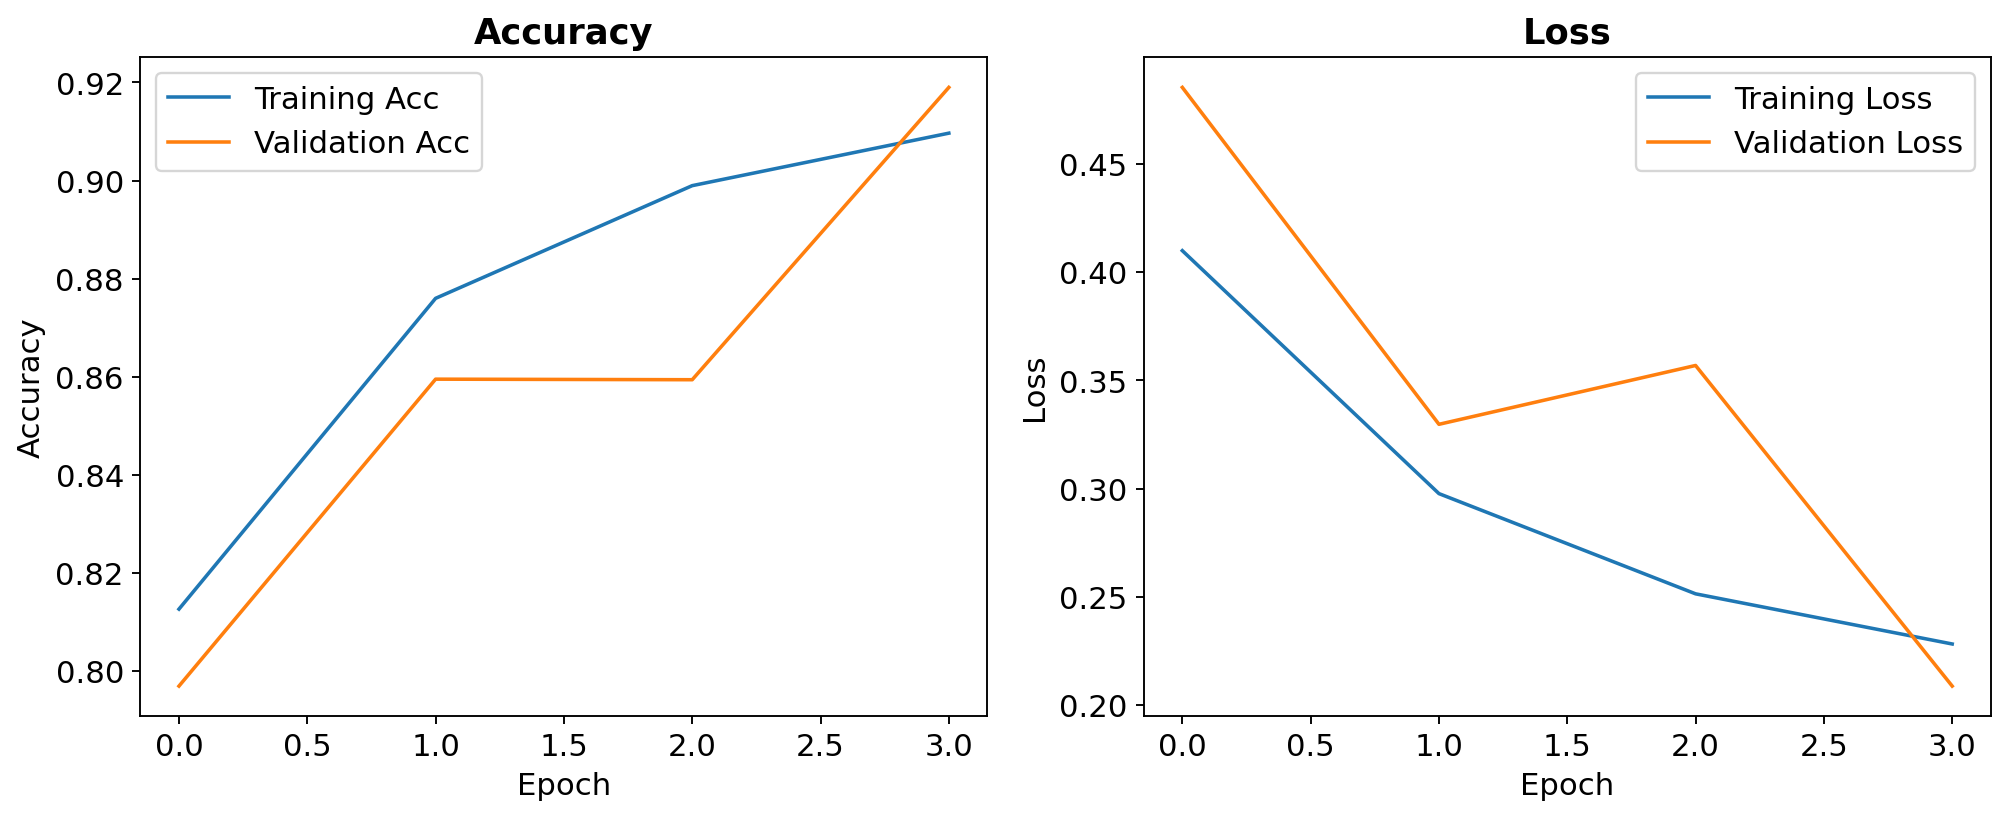

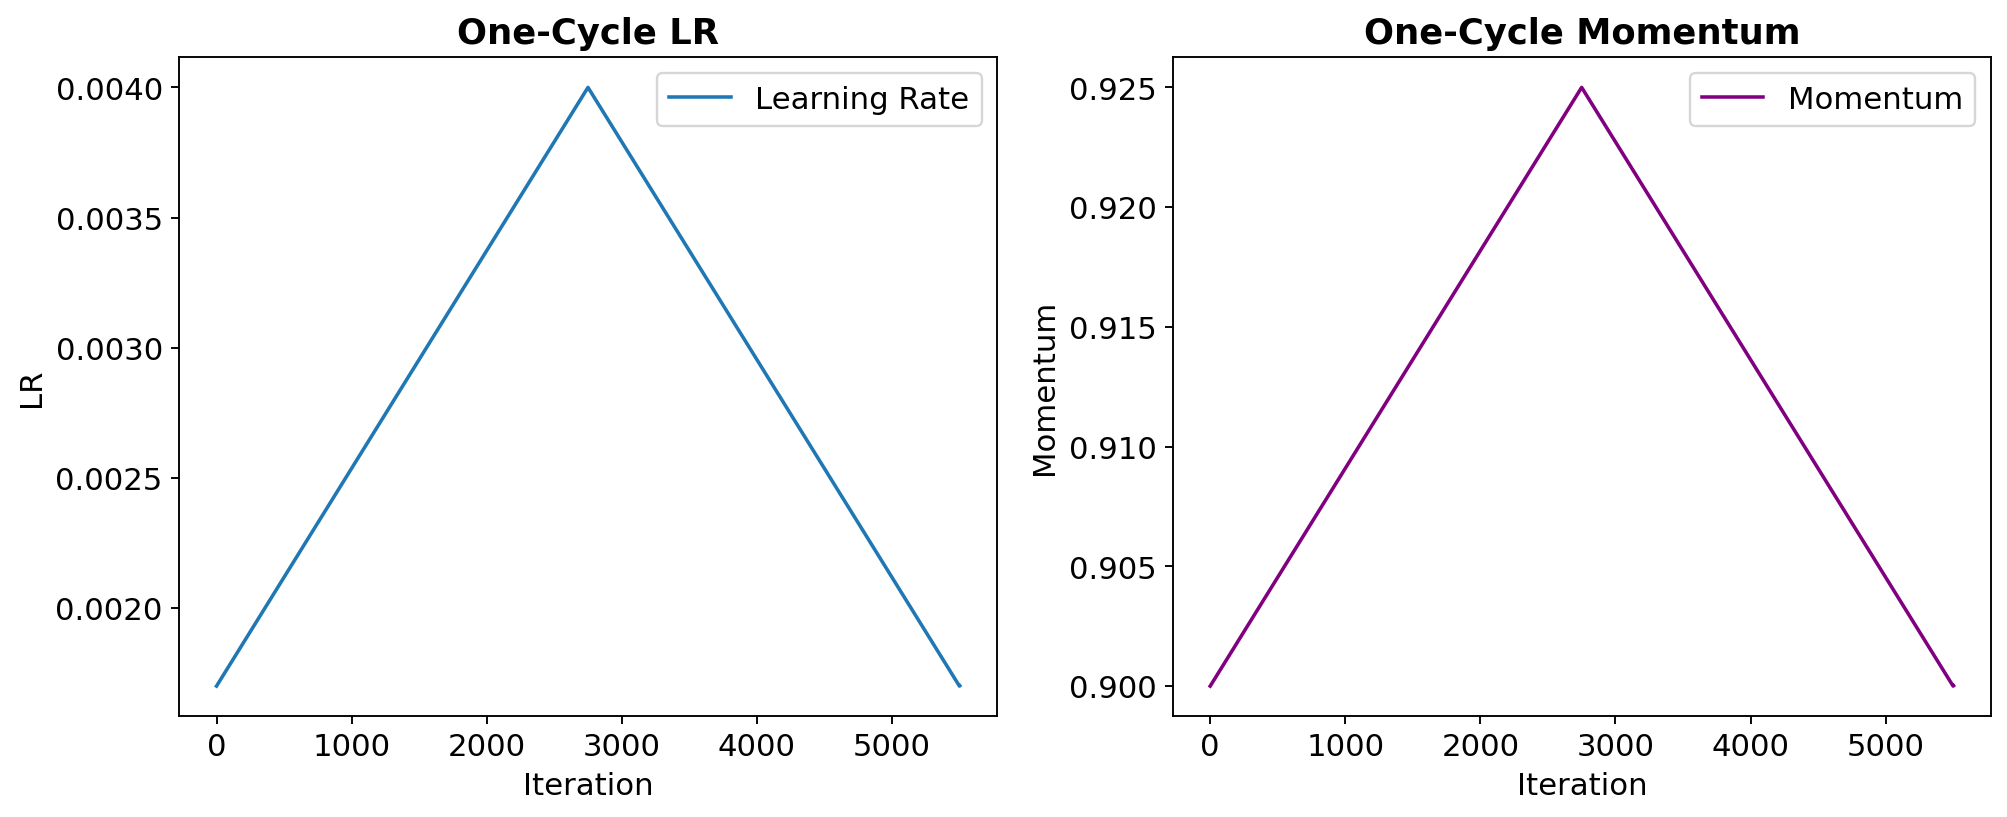

In [43]:
# epoch curves 
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(history.history['accuracy'], label='Training Acc')
ax[0].plot(history.history['val_accuracy'], label='Validation Acc')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Accuracy'); ax[0].set_title('Accuracy'); ax[0].legend()

ax[1].plot(history.history['loss'], label='Training Loss')
ax[1].plot(history.history['val_loss'], label='Validation Loss')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Loss'); ax[1].set_title('Loss'); ax[1].legend()
plt.tight_layout(); plt.show()

# one-cycle schedules (per-iteration) 
lr_hist = np.array(one_cycle.lr_history)
m_hist = np.array(one_cycle.m_history)
iters = np.array(one_cycle.it_history)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(iters, lr_hist, label='Learning Rate')
ax[0].set_xlabel('Iteration'); ax[0].set_ylabel('LR'); ax[0].set_title('One-Cycle LR'); ax[0].legend()

ax[1].plot(iters, m_hist, label='Momentum', color='purple')
ax[1].set_xlabel('Iteration'); ax[1].set_ylabel('Momentum'); ax[1].set_title('One-Cycle Momentum'); ax[1].legend()
plt.tight_layout(); plt.show()

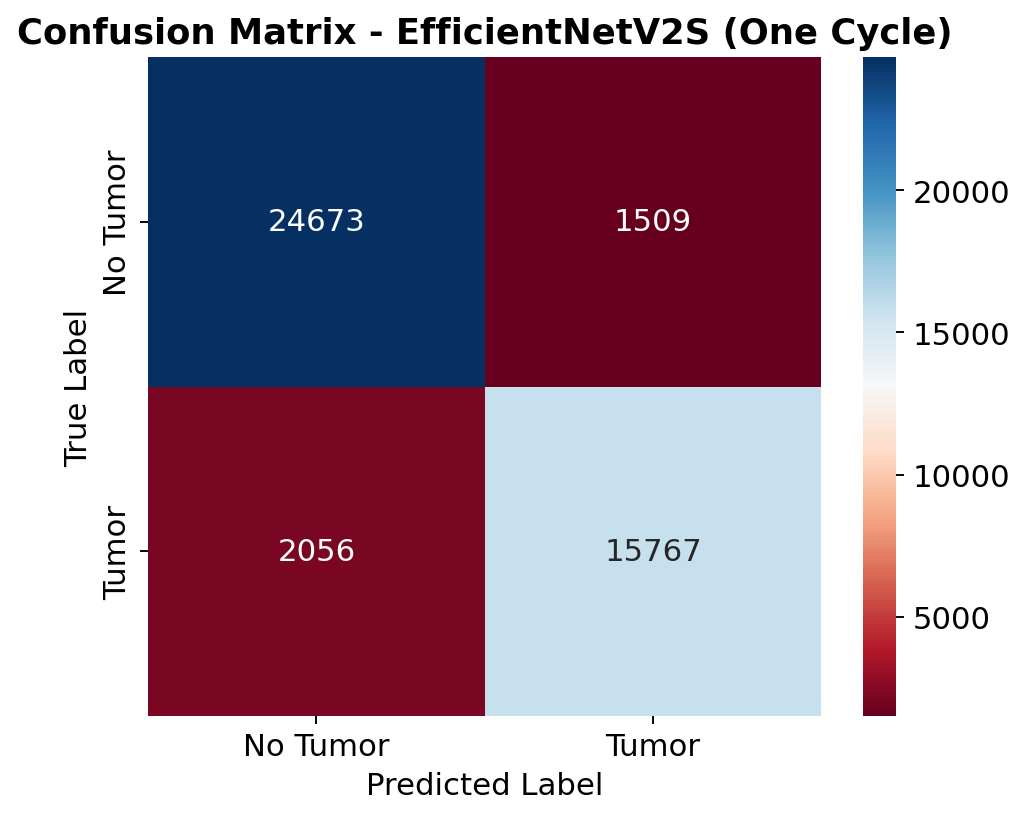

              precision    recall  f1-score   support

    No Tumor       0.92      0.94      0.93     26182
       Tumor       0.91      0.88      0.90     17823

    accuracy                           0.92     44005
   macro avg       0.92      0.91      0.92     44005
weighted avg       0.92      0.92      0.92     44005



In [44]:
# 1. Collect true labels from the dataset (no augmentation on val_ds)
y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0).astype(int)  # shape (N,)

# 2. Predict probabilities and binarize at 0.5
y_pred_probs = model.predict(val_ds, verbose=0).ravel()                      # shape (N,)
y_pred = (y_pred_probs >= 0.5).astype(int)

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu", xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - EfficientNetV2S (One Cycle)")
plt.tight_layout()
plt.show()
print(classification_report(y_true, y_pred, target_names=['No Tumor', 'Tumor']))

In [45]:
# from sklearn.metrics import roc_curve
# fpr, tpr, thr = roc_curve(y_true, y_pred_probs)
# best_idx = np.argmax(tpr - fpr)
# best_thr = thr[best_idx]
# print(f"Best threshold (Youden J): {best_thr:.3f}")

### Visualizing Misclassified Images

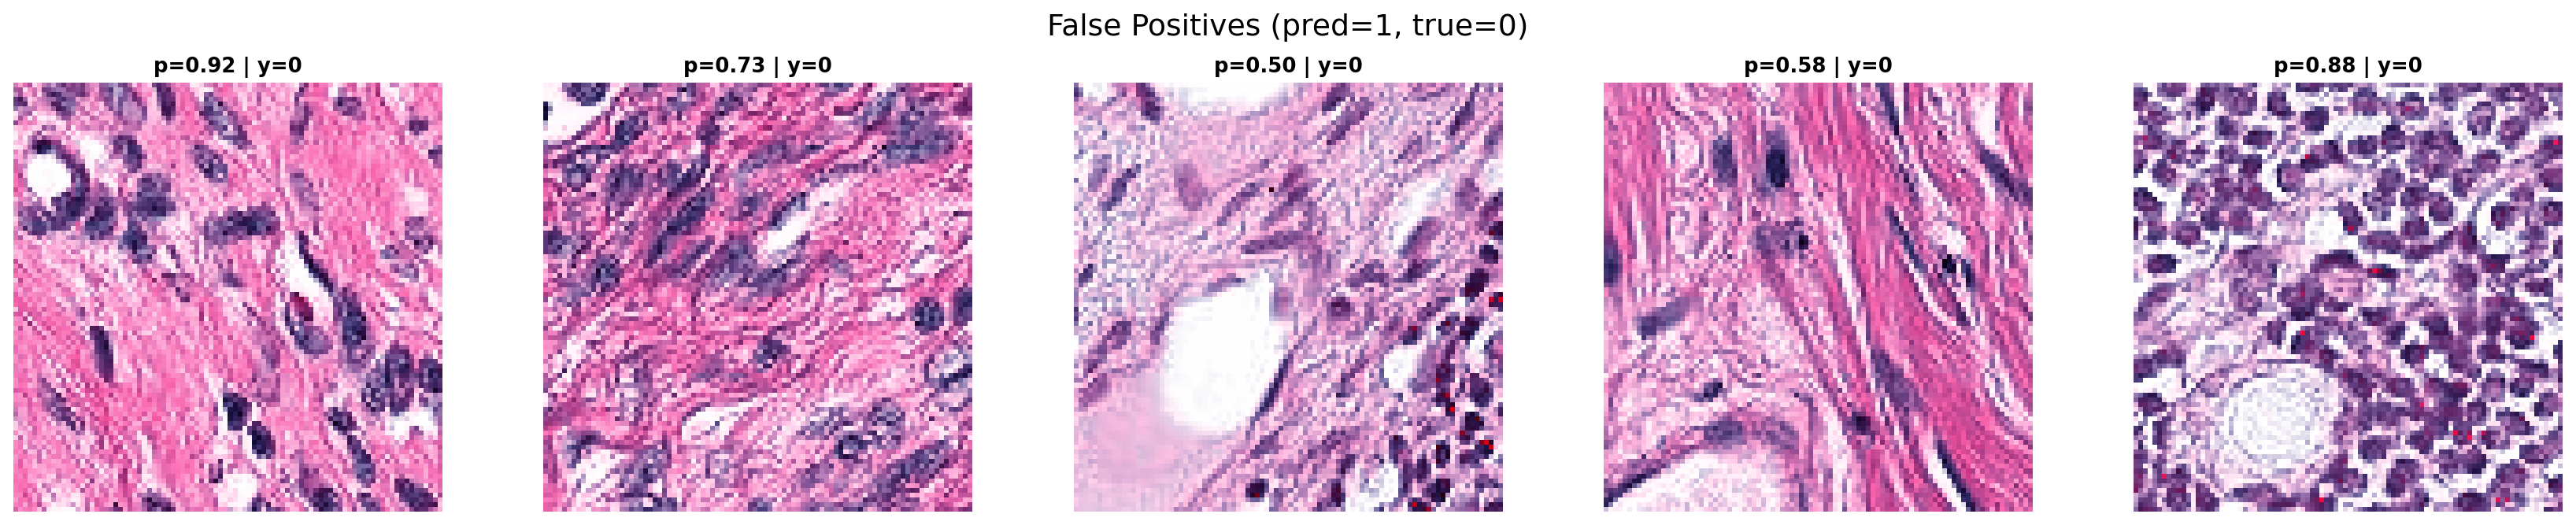

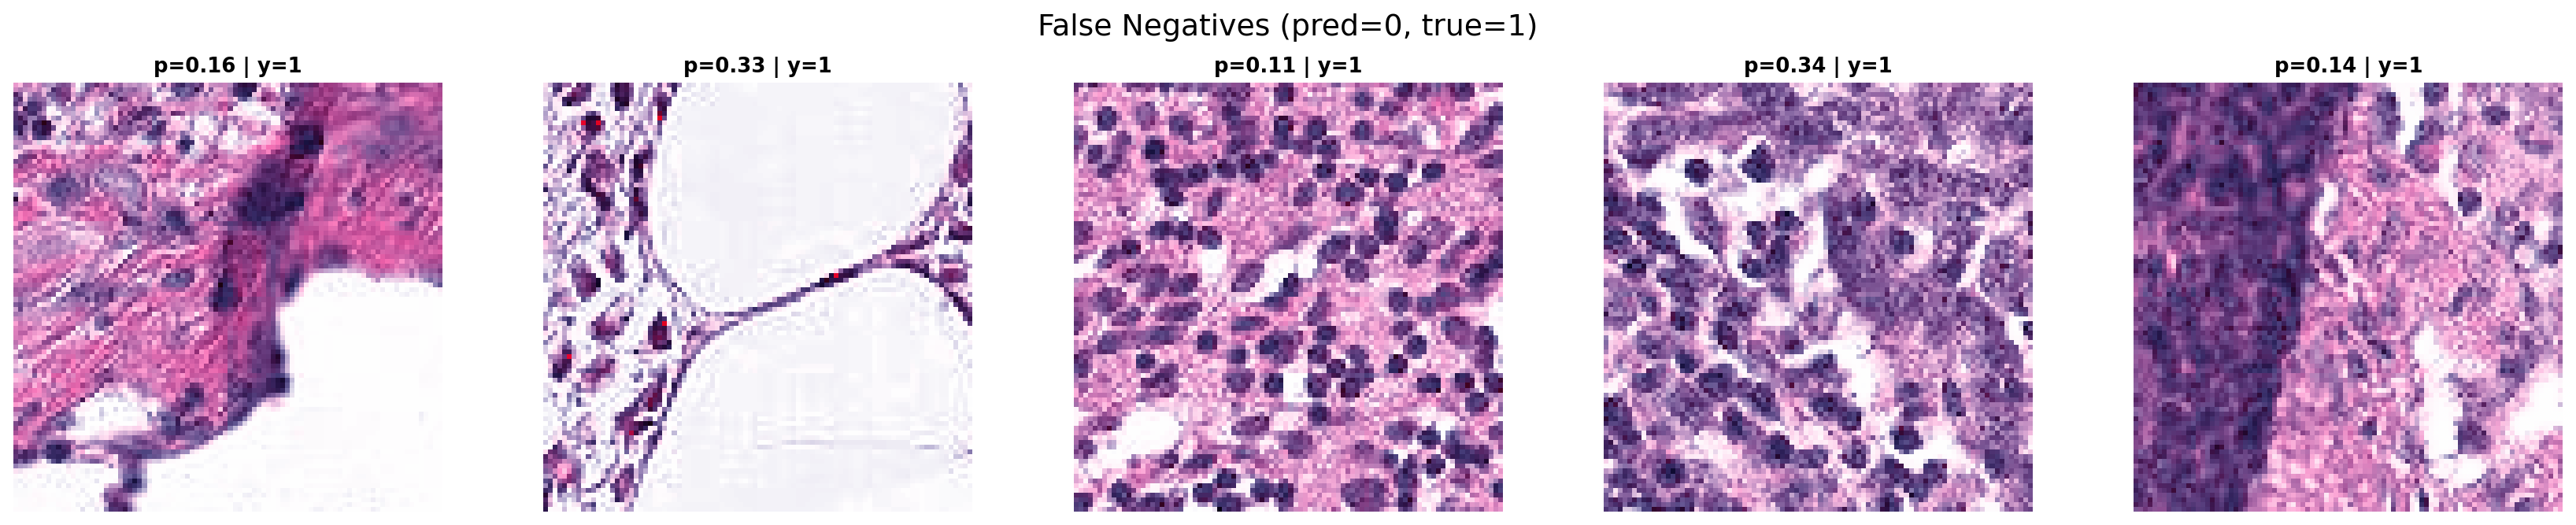

In [46]:
# misclassified indices 
false_positives = np.where((y_pred == 1) & (y_true == 0))[0]
false_negatives = np.where((y_pred == 0) & (y_true == 1))[0]

def plot_misclassified(indices, title, num_samples=5):
    """Plot misclassified *model inputs* (cached tiles) with preds."""
    if len(indices) == 0:
        print(f"No samples for: {title}")
        return
    k = int(min(num_samples, len(indices)))
    fig, axes = plt.subplots(1, k, figsize=(4*k, 4))
    if k == 1:
        axes = np.array([axes])
    fig.suptitle(title, fontsize=16)

    for ax, idx in zip(axes, indices[:k]):
        # show exactly what the model evaluated: cached tile, center-crop, no aug
        img = read_cropped_image(val_paths_full[idx], augment=False)  # float32 [0,1], 90x90x3
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"p={y_pred_probs[idx]:.2f} | y={int(y_true[idx])}", fontsize=11)

    plt.tight_layout(); plt.show()

plot_misclassified(false_positives, "False Positives (pred=1, true=0)")
plot_misclassified(false_negatives, "False Negatives (pred=0, true=1)")

In [52]:
import gc
# clear Keras backend session to free up memory before ViT
tf.keras.backend.clear_session()

# Python garbage collector
gc.collect()

1211

### Baseline Model Misclassified Results Analysis
False Positives:

- Appear lighter in staining overall
- More fibroblasts (these are the cells that look spindle shaped)

False Negatives:

- Appear darker in staining overall
- Nuclei appear closely packed
- Clear patterns in edges


Possible Improvements:
Variations in the staining and texture seem to be the contributing to misclassification most. I will try to apply stain normalization to reduce variance between slides so the model can focus in on the actual shape of tumerous cells. I report the results of this experiment here: After applying macenko normalization, I achieve very similar results. False negatives still have clear edge patterns and appear a little darker in staining. 

### 4. Implementing Vision Transformer (ViT Hybrid) Model
Here, I rebuild EfficientNetV2 and integrate transformer layers (Multi-Head Attention) on top. However, I do not use the One Cycle Policy here because it was created for CNN-based architectures. ViT requires a different training strategy, so, I use the trained EfficientNetV2S as a feature extractor and train the ViT-Hybrid model from scratch to better align with transformer learning dynamics. [ViT Paper](https://arxiv.org/pdf/1905.11946)


I use 8 attention heads because the number of attention heads is chosen based on the feature space size. More heads improve feature representation but increase memory usage. Since EfficientNetV2S already extracts rich features, 8 attention heads is a good balance between performance and efficiency. I chose key dimension = 64 because the key dimension controls how much each attention head focuses on different features. Common choices are 32, 64, 96, and 128. But if it is too low (32), the model may lack expressiveness. By contrast, if it is too high (128), there are more parameters, leading to overfitting and slower training.

To provide stable convergence, AdamW is used instead of SGD, and a Cosine Decay Schedule progressively lowers the learning rate. Training follows a 4 phase approach to progressively fine-tune different layers. In Phase 1, the EfficientNetV2S backbone is frozen, training only the classification head (128 → 1) for 7 epochs with a starting learning rate of 1e-4. Phase 2 unfreezes attention layers while keeping the EfficientNetV2S backbone frozen, reducing the LR to 1/3 of the initial value and training for 7 more epochs. In Phase 3, the last 100 layers of EfficientNetV2 are unfreezed, lowering the LR to 1/5 to prevent  forgetting and training for 5 epochs. Finally, in Phase 4, all layers are unfrozen (except BatchNorm), with the final LR reduced to 1/10 of the initial value. A Cosine Decay Schedule is applied over 15 epochs to ensure smooth convergence and prevent instability.

In [53]:
# LR scheduling / callbacks 
initial_lr = 1e-4
min_lr = initial_lr / 20.0

def cosine_decay(epoch, lr):
    # 15 epochs full cycle here; tweak as desired
    lr_new = initial_lr * 0.5 * (1 + np.cos(np.pi * epoch / 15.0))
    return max(lr_new, min_lr)

callbacks_vit = [
    tf.keras.callbacks.EarlyStopping(monitor='val_bce', patience=6, restore_best_weights=True),
    # keep plateau for phase 1/2 only (no cosine there)
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_bce', factor=0.2, patience=3, min_lr=1e-6),
]

callbacks_vit_finetune = [
    tf.keras.callbacks.EarlyStopping(monitor='val_bce', patience=6, restore_best_weights=True),
    # Use cosine in finetune; drop ReduceLROnPlateau to avoid conflicts
    tf.keras.callbacks.ModelCheckpoint(filepath='vit_hybrid_finetuned_model', monitor='val_bce', save_best_only=True, save_weights_only=False, mode='min', verbose=1),
    tf.keras.callbacks.LearningRateScheduler(cosine_decay)
]

# Positional embedding 
class PositionalEmbedding(Layer):
    def __init__(self, num_patches, embedding_dim):
        super().__init__()
        self.num_patches = int(num_patches)
        self.embedding_dim = int(embedding_dim)
        self.pos_embedding = self.add_weight(name="pos_embedding", shape=(1, self.num_patches, self.embedding_dim), initializer="random_normal"
        )
    def call(self, inputs):
        return inputs + self.pos_embedding

# Build ViT-hybrid
def build_vit_hybrid(input_shape=(crop_size, crop_size, 3), num_heads=8, key_dim=64, dropout_rate=0.4, l2_reg=5e-5, use_pretrained_backbone=True, load_trained_path="efficientnet_trained_model"):  
    if use_pretrained_backbone:
        # load your trained SavedModel (matches earlier save)
        backbone = tf.keras.models.load_model(load_trained_path, compile=False)
        # take the feature map output (include_top=False equivalent)
        # This finds the last 4D tensor (H,W,C) in the graph robustly:
        feat = None
        for lyr in reversed(backbone.layers):
            try:
                out = lyr.output
                if len(out.shape) == 4:
                    feat = out
                    break
            except Exception:
                continue
        if feat is None:
            # fallback: just use model.input->model.layers[-2] etc.,
            # but usually EfficientNetV2S backbone output is 4D.
            print("feat is None")
            feat = backbone.layers[-2].output
        base_model = Model(inputs=backbone.input, outputs=feat, name="efnv2s_backbone")
    else:
        # fresh imagenet backbone
        print("Using fresh imagenet backbone")
        base_raw = tf.keras.applications.EfficientNetV2S(weights="imagenet", include_top=False, input_shape=input_shape)
        base_model = Model(inputs=base_raw.input, outputs=base_raw.output, name="efnv2s_backbone")

    # get static (H,W,C) from output_shape (ints with fixed input)
    _, H, W, C = base_model.output_shape
    x = base_model.output                       # (None, H, W, C)
    x = Reshape((-1, C))(x)                     # (None, H*W, C)

    # positions
    num_patches = H * W
    x = PositionalEmbedding(num_patches, C)(x)  # (None, H*W, C)

    # transformer block (1 block; expand as desired)
    x_norm = LayerNormalization()(x)
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x_norm, x_norm)
    x = Add()([x_norm, attn])   # residual

    # head
    x = Flatten()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(128, activation='gelu', dtype="float16")(x)
    x = Dropout(dropout_rate)(x)
    out = Dense(1, activation='sigmoid', dtype="float32")(x)

    model = Model(inputs=base_model.input, outputs=out, name="vit_hybrid")
    return model, base_model

# Build model (uses cached datasets train_ds/val_ds)
model_vit_hybrid, base_model = build_vit_hybrid(input_shape=(crop_size, crop_size, 3), dropout_rate=0.3, l2_reg=0.05, use_pretrained_backbone=True, load_trained_path="efficientnet_trained_model")

# Phase 1: freeze backbone, train head
print("Phase 1: Training classification head...")
for layer in base_model.layers:
    layer.trainable = False

loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False, label_smoothing=0.05)

opt = AdamW(learning_rate=initial_lr, weight_decay=0.015, clipnorm=1.0)
model_vit_hybrid.compile(optimizer=opt, loss=loss_fn, metrics=[tf.keras.metrics.BinaryCrossentropy(name='bce'), 'accuracy', AUC(name='auc')])
history_phase1 = model_vit_hybrid.fit(train_ds, validation_data=val_ds, epochs=7, callbacks=callbacks_vit)

# Phase 2: warmup attention layers (unfreeze only MHA layers)
print("Phase 2: Warming up attention layers...")
for layer in model_vit_hybrid.layers:
    if isinstance(layer, MultiHeadAttention):
        layer.trainable = True

opt = AdamW(learning_rate=initial_lr/3.0, weight_decay=0.015, clipnorm=1.0)
model_vit_hybrid.compile(optimizer=opt, loss=loss_fn, metrics=[tf.keras.metrics.BinaryCrossentropy(name='bce'), 'accuracy', AUC(name='auc')])
history_phase2 = model_vit_hybrid.fit(train_ds, validation_data=val_ds, epochs=7, callbacks=callbacks_vit)

# Phase 3: fine-tune last ~100 backbone layers
print("Phase 3: Fine-tuning last layers...")
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= len(base_model.layers) - 100)

opt = AdamW(learning_rate=initial_lr/5.0, clipnorm=1.0)
model_vit_hybrid.compile(optimizer=opt, loss=loss_fn, metrics=[tf.keras.metrics.BinaryCrossentropy(name='bce'), 'accuracy', AUC(name='auc')])
history_phase3 = model_vit_hybrid.fit(train_ds, validation_data=val_ds, epochs=5, callbacks=callbacks_vit)

# Phase 4: unfreeze backbone (keep BN frozen), cosine schedule
print("Phase 4: Fine-tuning entire model...")
for layer in base_model.layers:
    layer.trainable = True
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

opt = AdamW(learning_rate=initial_lr/10.0, clipnorm=1.0)
model_vit_hybrid.compile(optimizer=opt, loss=loss_fn, metrics=[tf.keras.metrics.BinaryCrossentropy(name='bce'), 'accuracy', AUC(name='auc')])
history_vit_hybrid = model_vit_hybrid.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks_vit_finetune)

Phase 1: Training classification head...
Epoch 1/7
1376/1376 [==============================] - 586s 421ms/step - loss: 0.3485 - bce: 0.2777 - accuracy: 0.9005 - auc: 0.9506 - val_loss: 0.2819 - val_bce: 0.2156 - val_accuracy: 0.9175 - val_auc: 0.9700 - lr: 1.0000e-04
Epoch 2/7
1376/1376 [==============================] - 580s 421ms/step - loss: 0.3108 - bce: 0.2488 - accuracy: 0.9131 - auc: 0.9617 - val_loss: 0.2788 - val_bce: 0.2140 - val_accuracy: 0.9181 - val_auc: 0.9705 - lr: 1.0000e-04
Epoch 3/7
1376/1376 [==============================] - 578s 420ms/step - loss: 0.3012 - bce: 0.2391 - accuracy: 0.9147 - auc: 0.9634 - val_loss: 0.2788 - val_bce: 0.2186 - val_accuracy: 0.9189 - val_auc: 0.9706 - lr: 1.0000e-04
Epoch 4/7
1376/1376 [==============================] - 576s 419ms/step - loss: 0.2966 - bce: 0.2346 - accuracy: 0.9149 - auc: 0.9636 - val_loss: 0.2806 - val_bce: 0.2170 - val_accuracy: 0.9194 - val_auc: 0.9707 - lr: 1.0000e-04
Epoch 5/7
1376/1376 [==========================

2025-08-28 15:40:07.625970: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape invit_hybrid/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1376/1376 [==============================] - 583s 411ms/step - loss: 0.2898 - bce: 0.2282 - accuracy: 0.9158 - auc: 0.9657 - val_loss: 0.2761 - val_bce: 0.2122 - val_accuracy: 0.9202 - val_auc: 0.9716 - lr: 2.0000e-05
Epoch 2/5
1376/1376 [==============================] - 565s 410ms/step - loss: 0.2867 - bce: 0.2247 - accuracy: 0.9167 - auc: 0.9668 - val_loss: 0.2739 - val_bce: 0.2097 - val_accuracy: 0.9211 - val_auc: 0.9720 - lr: 2.0000e-05
Epoch 3/5
1376/1376 [==============================] - 565s 410ms/step - loss: 0.2851 - bce: 0.2227 - accuracy: 0.9175 - auc: 0.9675 - val_loss: 0.2732 - val_bce: 0.2089 - val_accuracy: 0.9214 - val_auc: 0.9721 - lr: 2.0000e-05
Epoch 4/5
1376/1376 [==============================] - 567s 412ms/step - loss: 0.2854 - bce: 0.2231 - accuracy: 0.9178 - auc: 0.9673 - val_loss: 0.2739 - val_bce: 0.2065 - val_accuracy: 0.9218 - val_auc: 0.9725 - lr: 2.0000e-05
Epoch 5/5
1376/1376 [==============================] - 565s 410ms/step - loss: 0.2836 - bce: 0.221

2025-08-28 16:27:34.555759: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape invit_hybrid/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1376/1376 [==============================] - ETA: 0s - loss: 0.3067 - bce: 0.2473 - accuracy: 0.9089 - auc: 0.9593      
Epoch 1: val_bce improved from inf to 0.20345, saving model to vit_hybrid_finetuned_model
INFO:tensorflow:Assets written to: vit_hybrid_finetuned_model/assets


...

1376/1376 [==============================] - 683s 497ms/step - loss: 0.2124 - bce: 0.1369 - accuracy: 0.9580 - auc: 0.9868 - val_loss: 0.2098 - val_bce: 0.1357 - val_accuracy: 0.9548 - val_auc: 0.9886 - lr: 9.5492e-06
Epoch 14/15
1376/1376 [==============================] - ETA: 0s - loss: 0.2104 - bce: 0.1346 - accuracy: 0.9585 - auc: 0.9870   
Epoch 14: val_bce improved from 0.13570 to 0.13330, saving model to vit_hybrid_finetuned_model
INFO:tensorflow:Assets written to: vit_hybrid_finetuned_model/assets


INFO:tensorflow:Assets written to: vit_hybrid_finetuned_model/assets


1376/1376 [==============================] - 708s 515ms/step - loss: 0.2104 - bce: 0.1346 - accuracy: 0.9585 - auc: 0.9870 - val_loss: 0.2099 - val_bce: 0.1333 - val_accuracy: 0.9548 - val_auc: 0.9887 - lr: 5.0000e-06
Epoch 15/15
1376/1376 [==============================] - ETA: 0s - loss: 0.2092 - bce: 0.1332 - accuracy: 0.9588 - auc: 0.9874   
Epoch 15: val_bce improved from 0.13330 to 0.13291, saving model to vit_hybrid_finetuned_model
INFO:tensorflow:Assets written to: vit_hybrid_finetuned_model/assets


INFO:tensorflow:Assets written to: vit_hybrid_finetuned_model/assets


1376/1376 [==============================] - 673s 489ms/step - loss: 0.2092 - bce: 0.1332 - accuracy: 0.9588 - auc: 0.9874 - val_loss: 0.2097 - val_bce: 0.1329 - val_accuracy: 0.9549 - val_auc: 0.9887 - lr: 5.0000e-06


### Evaluate Performance

The ViT-Hybrid model achieved a validation accuracy of 95.84% and an AUC of 0.9900, showing stronger performance in distinguishing tumor from non-tumor patches. The confusion matrix shows improved recall for both no tumore detection (0.97) and tumor detection (0.94) compared to EfficientNetV2S, meaning that ViT-Hybrid captures long range dependencies effectively. However, the validation accuracy curve suggests some fluctuations, likely due to the sensitivity of attention mechanisms to hyperparameter tuning. Despite this, the higher F1-score (0.96/.95) across both classes proves the model's balanced performance, making it a great alternative to pure CNN-based architectures for histopathology classification. 

In [54]:
test_loss_vit, test_bce_vit, test_acc_vit, test_auc_vit = model_vit_hybrid.evaluate(val_ds)
print(f"ViT-Hybrid Validation Loss (objective): {test_loss_vit:.4f}")
print(f"ViT-Hybrid Validation BCE (metric): {test_bce_vit:.4f}")
print(f"ViT-Hybrid Validation Accuracy: {test_acc_vit:.4f}")
print(f"ViT-Hybrid Validation AUC: {test_auc_vit:.4f}")


344/344 [==============================] - 14s 39ms/step - loss: 0.2097 - bce: 0.1329 - accuracy: 0.9549 - auc: 0.9887
ViT-Hybrid Validation Loss (objective): 0.2097
ViT-Hybrid Validation BCE (metric): 0.1329
ViT-Hybrid Validation Accuracy: 0.9549
ViT-Hybrid Validation AUC: 0.9887


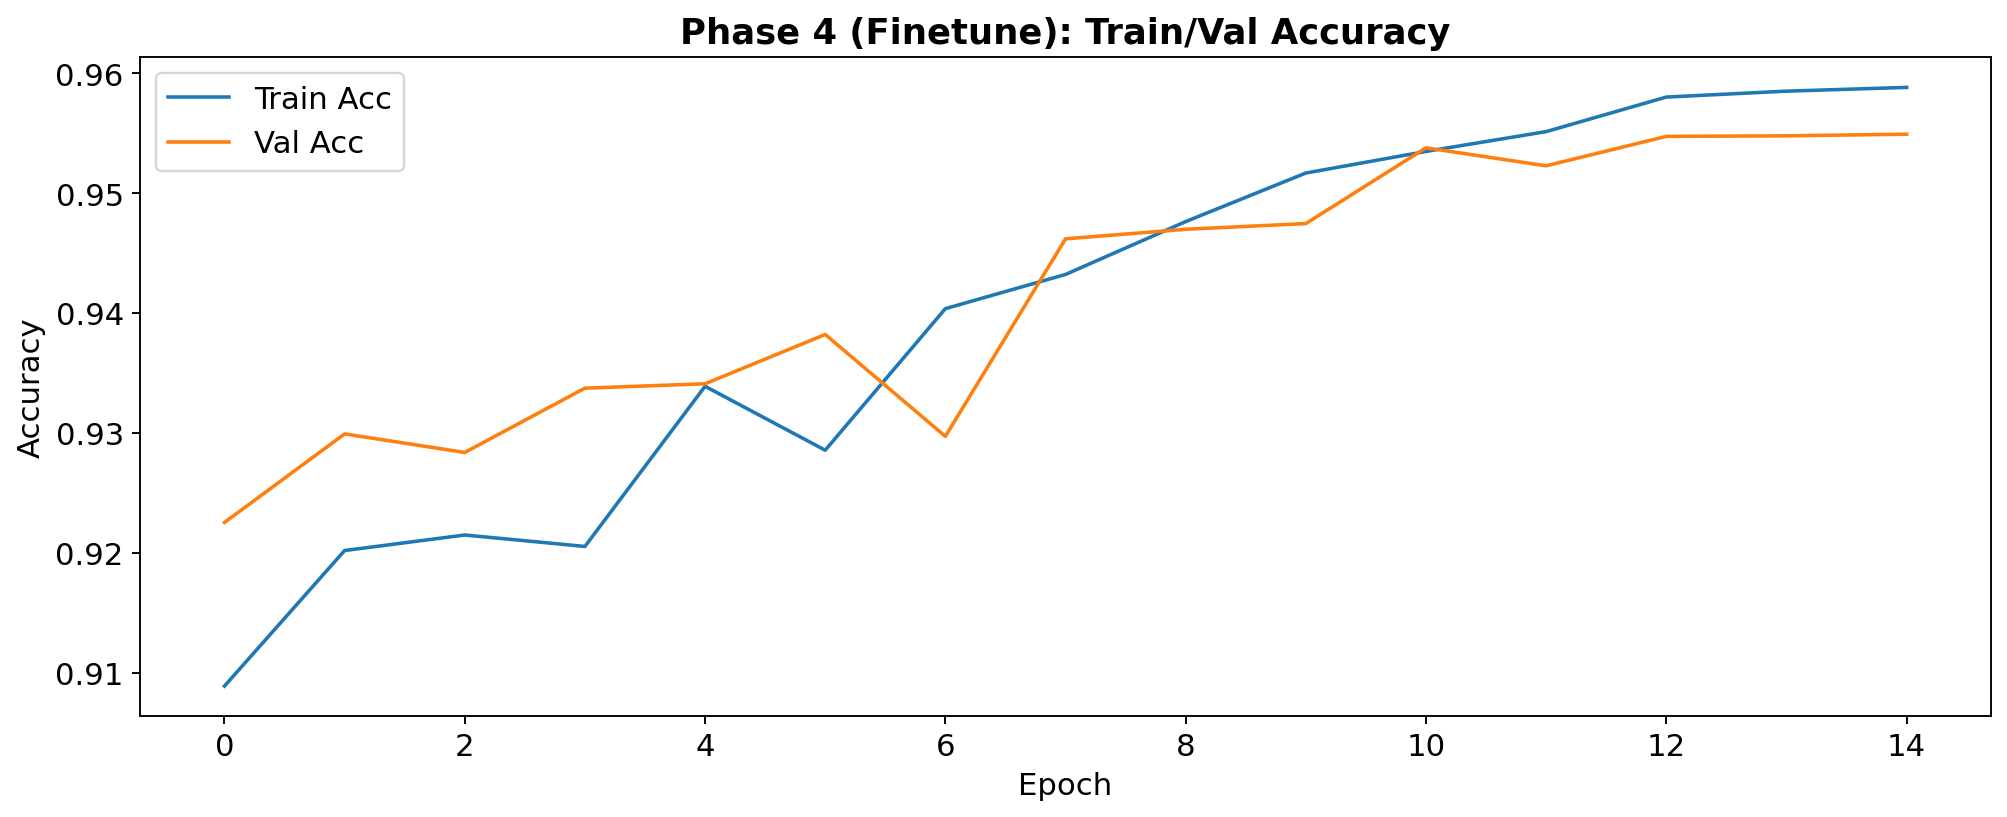

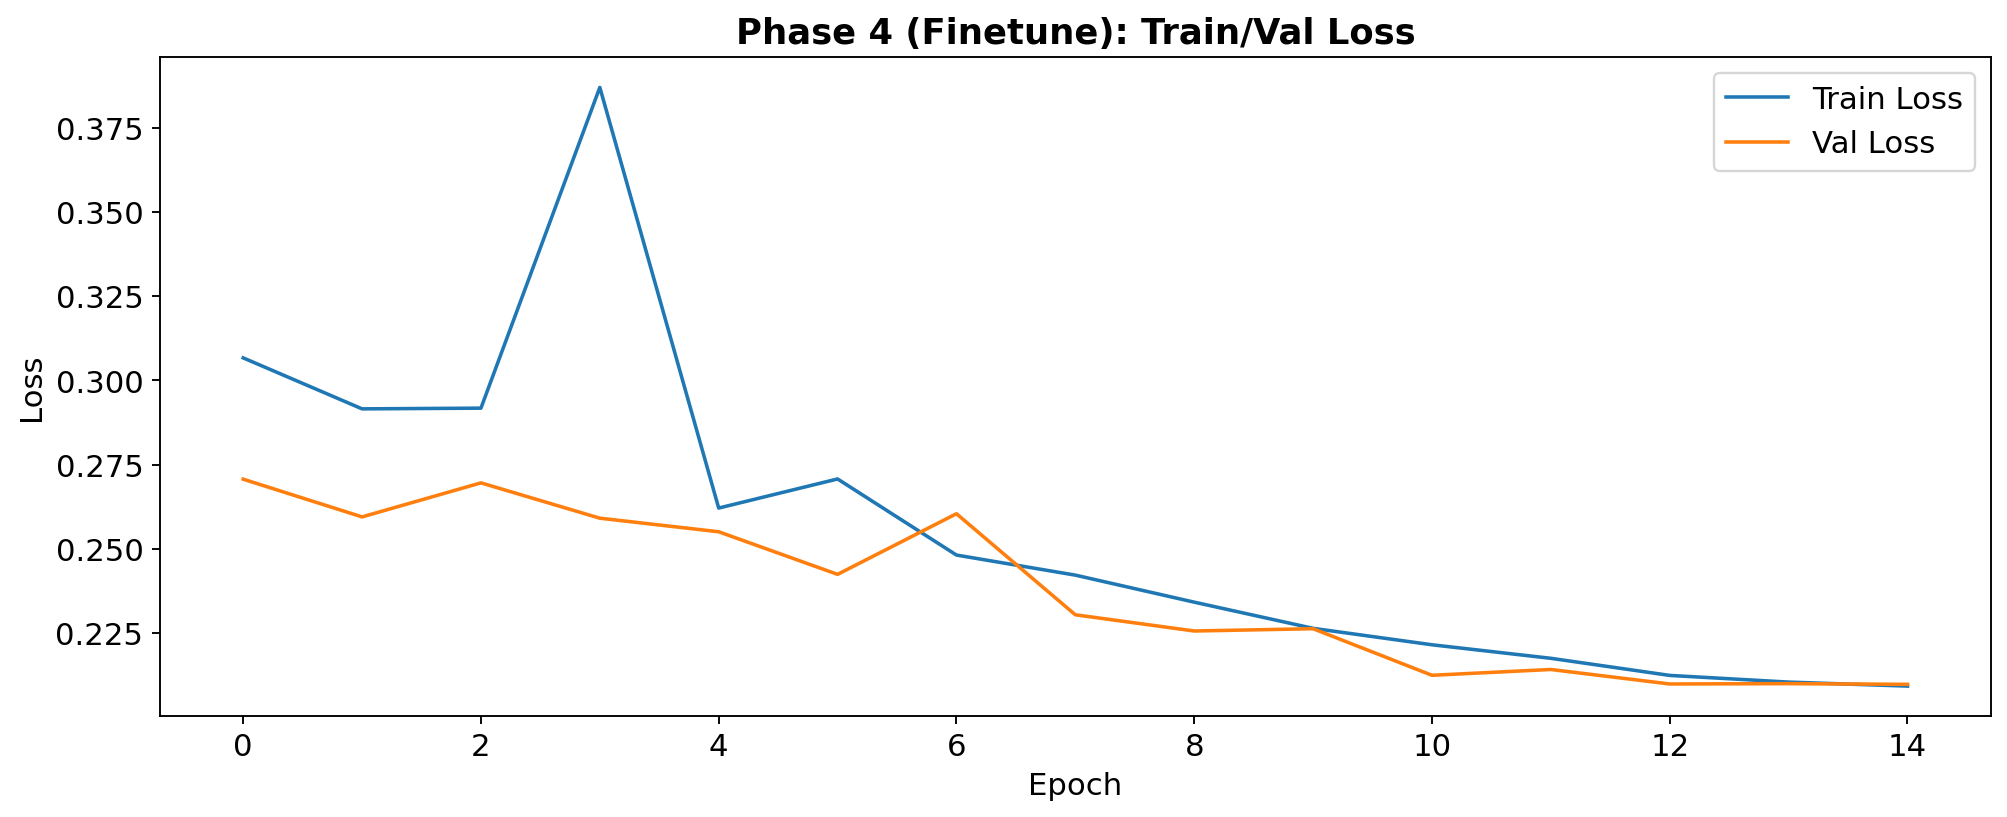

In [55]:
# Accuracy
plt.figure(figsize=(12,5))
plt.plot(history_vit_hybrid.history['accuracy'],     label='Train Acc')
plt.plot(history_vit_hybrid.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Phase 4 (Finetune): Train/Val Accuracy')
plt.legend(); plt.tight_layout(); plt.show()

# Loss (objective)
plt.figure(figsize=(12,5))
plt.plot(history_vit_hybrid.history['loss'],     label='Train Loss')
plt.plot(history_vit_hybrid.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Phase 4 (Finetune): Train/Val Loss')
plt.legend(); plt.tight_layout(); plt.show()

344/344 [==============================] - 14s 36ms/step


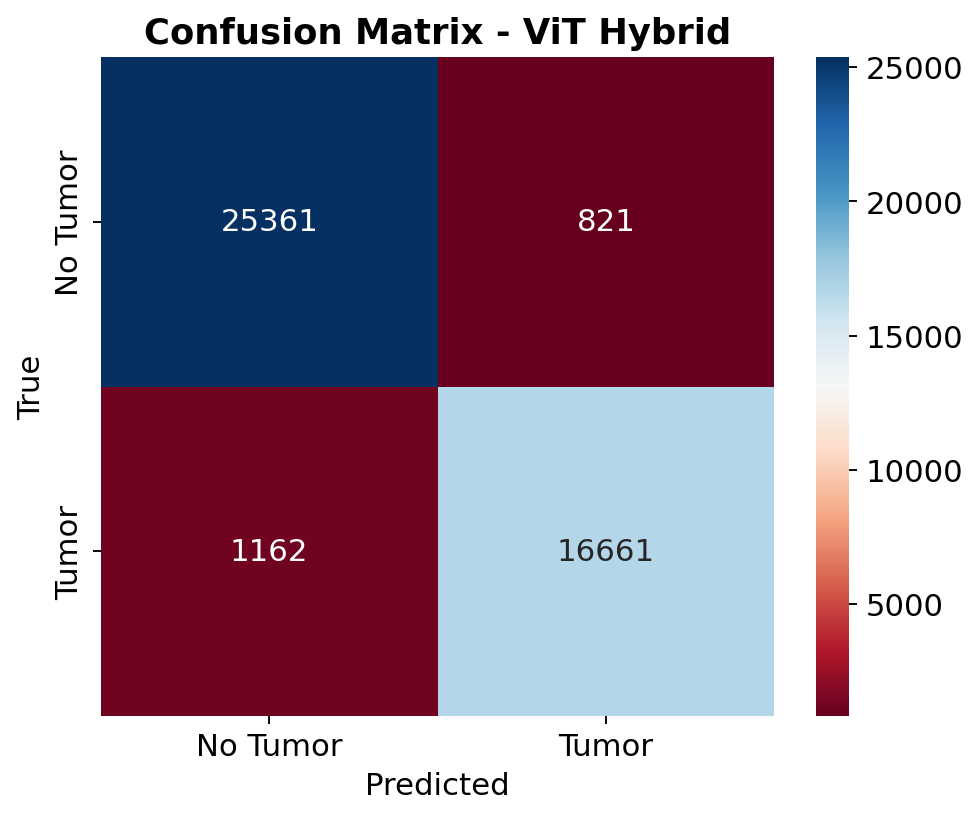

              precision    recall  f1-score   support

    No Tumor       0.96      0.97      0.96     26182
       Tumor       0.95      0.93      0.94     17823

    accuracy                           0.95     44005
   macro avg       0.95      0.95      0.95     44005
weighted avg       0.95      0.95      0.95     44005



In [56]:
# Collect labels & preds
y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0).astype(int).ravel()
y_pred_probs = model_vit_hybrid.predict(val_ds).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu",
            xticklabels=['No Tumor','Tumor'], yticklabels=['No Tumor','Tumor'])
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix - ViT Hybrid"); plt.tight_layout(); plt.show()

# Classification report
print(classification_report(y_true, y_pred, target_names=['No Tumor','Tumor']))

### Final Model Comparison and Kaggle Submission

Test-Time Augmentation (TTA) is applied during inference to improve model robustness by averaging predictions from multiple augmented versions of the same image. Unlike training augmentation, which helps with generalization, TTA helps reduce prediction variance by simulating different  transformations of each test image. Here, the same augmentation performed during training are randomly applied to create 30 augmented versions per test image. The final prediction is obtained by averaging across all iterations. The best-performing model (ViT-Hybrid) is automatically selected based on validation AUC, ensuring optimal performance for final submission.

In [57]:
# Unlabeled dataset builder (cached) 
def build_tf_dataset_cached_unlabeled(image_paths, batch_size=128, dataset_type="val"):
    """
    image_paths: list/np.array of .npz (preferred), .npy, or .tif paths
    dataset_type: "val" -> no aug, "train" -> enable aug (used for TTA)
    """
    paths_tf = tf.convert_to_tensor(image_paths, dtype=tf.string)

    def _map_fn(path_tensor):
        img_f32 = tf.py_function(
            func=lambda q: _py_load_and_preprocess_cached(q, dataset_type),
            inp=[path_tensor],
            Tout=tf.float32,   # returns float32 [crop, crop, 3]
        )
        img_f32.set_shape([crop_size, crop_size, 3])
        return tf.cast(img_f32, tf.float16)  # mixed precision input

    ds = tf.data.Dataset.from_tensor_slices(paths_tf)
    ds = ds.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Collect cached TEST paths 
test_npz_paths = sorted(
    os.path.join(test_path_macenko, f)
    for f in os.listdir(test_path_macenko)
    if f.endswith(".npz")
)
assert test_npz_paths, f"No cached files found in {test_path_macenko}"

test_ids = [os.path.splitext(os.path.basename(p))[0] for p in test_npz_paths]

# Baseline (no-TTA) test predictions from both models
test_ds_no_tta = build_tf_dataset_cached_unlabeled(test_npz_paths, batch_size=128, dataset_type="val")
preds_eff = model.predict(test_ds_no_tta, verbose=1).ravel()
preds_vit = model_vit_hybrid.predict(test_ds_no_tta, verbose=1).ravel()

# Save submissions (ensure folder exists)
os.makedirs("submissions", exist_ok=True)
pd.DataFrame({'id': test_ids, 'label': preds_eff}).to_csv('submissions/submission_EfficientNetV2S.csv', index=False)
pd.DataFrame({'id': test_ids, 'label': preds_vit}).to_csv('submissions/submission_ViT_Hybrid.csv', index=False)

# Validation AUC comparison 
# Baseline model returns: loss, accuracy, auc
eff_loss, eff_acc, eff_auc = model.evaluate(val_ds, verbose=0)

# ViT model returns: loss, bce (metric), accuracy, auc   
vit_loss, vit_bce, vit_acc, vit_auc = model_vit_hybrid.evaluate(val_ds, verbose=0)

print(f"EffNetV2S  — Val  Loss: {eff_loss:.4f} | Acc: {eff_acc:.4f} | AUC: {eff_auc:.4f}")
print(f"ViT-Hybrid — Val  Loss: {vit_loss:.4f} | BCE: {vit_bce:.4f} | Acc: {vit_acc:.4f} | AUC: {vit_auc:.4f}")

best_model, best_model_name, best_auc = (
    (model, "EfficientNetV2S", eff_auc) if eff_auc >= vit_auc
    else (model_vit_hybrid, "ViT-Hybrid", vit_auc)
)
print(f"Best Model Selected: {best_model_name} with AUC: {best_auc:.4f}")

# TTA 
def tta_inference(model, image_paths, tta_times=30, batch_size=128):
    """
    Uses dataset_type='train' to enable augmentation inside cached loader.
    Averages probabilities across tta_times passes.
    """
    all_preds = np.zeros((len(image_paths), tta_times), dtype=np.float32)
    for i in range(tta_times):
        print(f"TTA iteration {i+1}/{tta_times}")
        tta_ds = build_tf_dataset_cached_unlabeled(image_paths, batch_size=batch_size, dataset_type="train")
        all_preds[:, i] = model.predict(tta_ds, verbose=1).ravel()
    return all_preds.mean(axis=1)

tta_preds = tta_inference(best_model, test_npz_paths, tta_times=30, batch_size=128)
pd.DataFrame({'id': test_ids, 'label': tta_preds}).to_csv('submissions/submission_TTA.csv', index=False)
print("Final TTA Submission saved to submissions/submission_TTA.csv")

449/449 [==============================] - 131s 289ms/step
EffNetV2S  — Val  Loss: 0.2087 | Acc: 0.9190 | AUC: 0.9707
ViT-Hybrid — Val  Loss: 0.2097 | BCE: 0.1329 | Acc: 0.9549 | AUC: 0.9887
Best Model Selected: ViT-Hybrid with AUC: 0.9887
TTA iteration 1/30
449/449 [==============================] - 191s 426ms/step
TTA iteration 2/30
449/449 [==============================] - 192s 427ms/step
TTA iteration 3/30
449/449 [==============================] - 192s 426ms/step
TTA iteration 4/30
449/449 [==============================] - 192s 427ms/step
TTA iteration 5/30
449/449 [==============================] - 192s 427ms/step
TTA iteration 6/30
449/449 [==============================] - 192s 427ms/step
TTA iteration 7/30
449/449 [==============================] - 191s 426ms/step
TTA iteration 8/30
449/449 [==============================] - 192s 427ms/step
TTA iteration 9/30
449/449 [==============================] - 191s 426ms/step
TTA iteration 10/30
449/449 [=============================

### EfficientNetV2S Kaggle Submission Results: Private Score: 0.9477 Public Score: 0.9384

### ViT Hybrid Kaggle Submission Results: Private Score: 0.9610 Public Score: 0.9565

### ViT Hybrid Model with TTA Kaggle Submission Results: Private Score: 0.9680 Public Score: 0.9647

### Model Averaging

In [60]:
vit_df = pd.read_csv('submissions/submission_ViT_Hybrid.csv')
eff_df = pd.read_csv('submissions/submission_EfficientNetV2S.csv')
tta_df = pd.read_csv('submissions/submission_TTA.csv')

# merge on id
ensemble_df = vit_df.merge(eff_df, on='id', suffixes=('_vit', '_eff'))
ensemble_df = ensemble_df.merge(tta_df, on='id')
ensemble_df.rename(columns={'label': 'label_tta'}, inplace=True)

# avg predictions
ensemble_df['label'] = (ensemble_df['label_vit'] + ensemble_df['label_eff'] + ensemble_df['label_tta']) / 3

# only keep id and the averaged label
final_submission = ensemble_df[['id', 'label']]

# save to CSV
final_submission.to_csv('submission_ensemble.csv', index=False)
print("Ensembled submission saved to 'submission_ensemble.csv'")

Ensembled submission saved to 'submission_ensemble.csv'


### Model Average Kaggle Submission Results: Private Score: 0.9655 Public Score: 0.9597

In [62]:
# give most weight to TTA then ViT then Eff
weight_vit = 0.3
weight_eff = 0.1
weight_tta = 0.6

# weighted averaging
ensemble_df['label'] = (weight_vit * ensemble_df['label_vit'] + weight_eff * ensemble_df['label_eff'] + weight_tta * ensemble_df['label_tta'])

# only keepid and the weighted label
final_submission = ensemble_df[['id', 'label']]

# save to CSV
final_submission.to_csv('submission_ensemble_weighted.csv', index=False)
print("Weighted ensemble submission saved to 'submission_ensemble_weighted.csv'")

Weighted ensemble submission saved to 'submission_ensemble_weighted.csv'


### Model Average Weighted Kaggle Submission Results: Private Score: 0.9680 Public Score: 0.9633


In [ ]:
from sklearn.metrics import roc_auc_score

# get validation probs for each model (NO TTA for speed)
val_paths_full = [os.path.join(val_path_macenko, f"{i}.npz") for i in val_df['id']]
y_val = val_df['label'].values.astype(np.float32)

val_ds_noaug = build_tf_dataset_cached(val_paths_full, y_val, batch_size=128, shuffle=False, dataset_type='val')
val_eff = model.predict(val_ds_noaug, verbose=0).ravel()
val_vit = model_vit_hybrid.predict(val_ds_noaug, verbose=0).ravel()

# make a VAL TTA version of the ViT 
def tta_inference_val(model, paths, tta_times=8, batch_size=128):
    all_preds = np.zeros((len(paths), tta_times), dtype=np.float32)
    for i in range(tta_times):
        ds_aug = build_tf_dataset_cached_unlabeled(paths, batch_size=batch_size, dataset_type="train")  # aug on
        all_preds[:, i] = model.predict(ds_aug, verbose=0).ravel()
    return all_preds.mean(axis=1)

val_tta = tta_inference_val(model_vit_hybrid, val_paths_full, tta_times=8, batch_size=128)

# search weights on the simplex
def objective(trial):
    w_vit = trial.suggest_float("w_vit", 0.0, 1.0)
    w_eff = trial.suggest_float("w_eff", 0.0, 1.0)
    w_tta = trial.suggest_float("w_tta", 0.0, 1.0)
    s = w_vit + w_eff + w_tta + 1e-12
    w = np.array([w_vit, w_eff, w_tta]) / s
    blended = w[0]*val_vit + w[1]*val_eff + w[2]*val_tta
    return -roc_auc_score(y_val, blended)  # minimize negative AUC

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200, show_progress_bar=False)

best = study.best_params
w = np.array([best["w_vit"], best["w_eff"], best["w_tta"]])
w = w / w.sum()
print("Best simplex weights (vit, eff, tta):", w)

# preds_vit, preds_eff, tta_preds
blended_test = w[0]*preds_vit + w[1]*preds_eff + w[2]*tta_preds
pd.DataFrame({'id': test_ids, 'label': blended_test}).to_csv('submission_optuna_blend.csv', index=False)

### Optuna Blend Kaggle Submission Results: Private Score: 0.9681 Public Score: 0.9643


# Final Submission Results

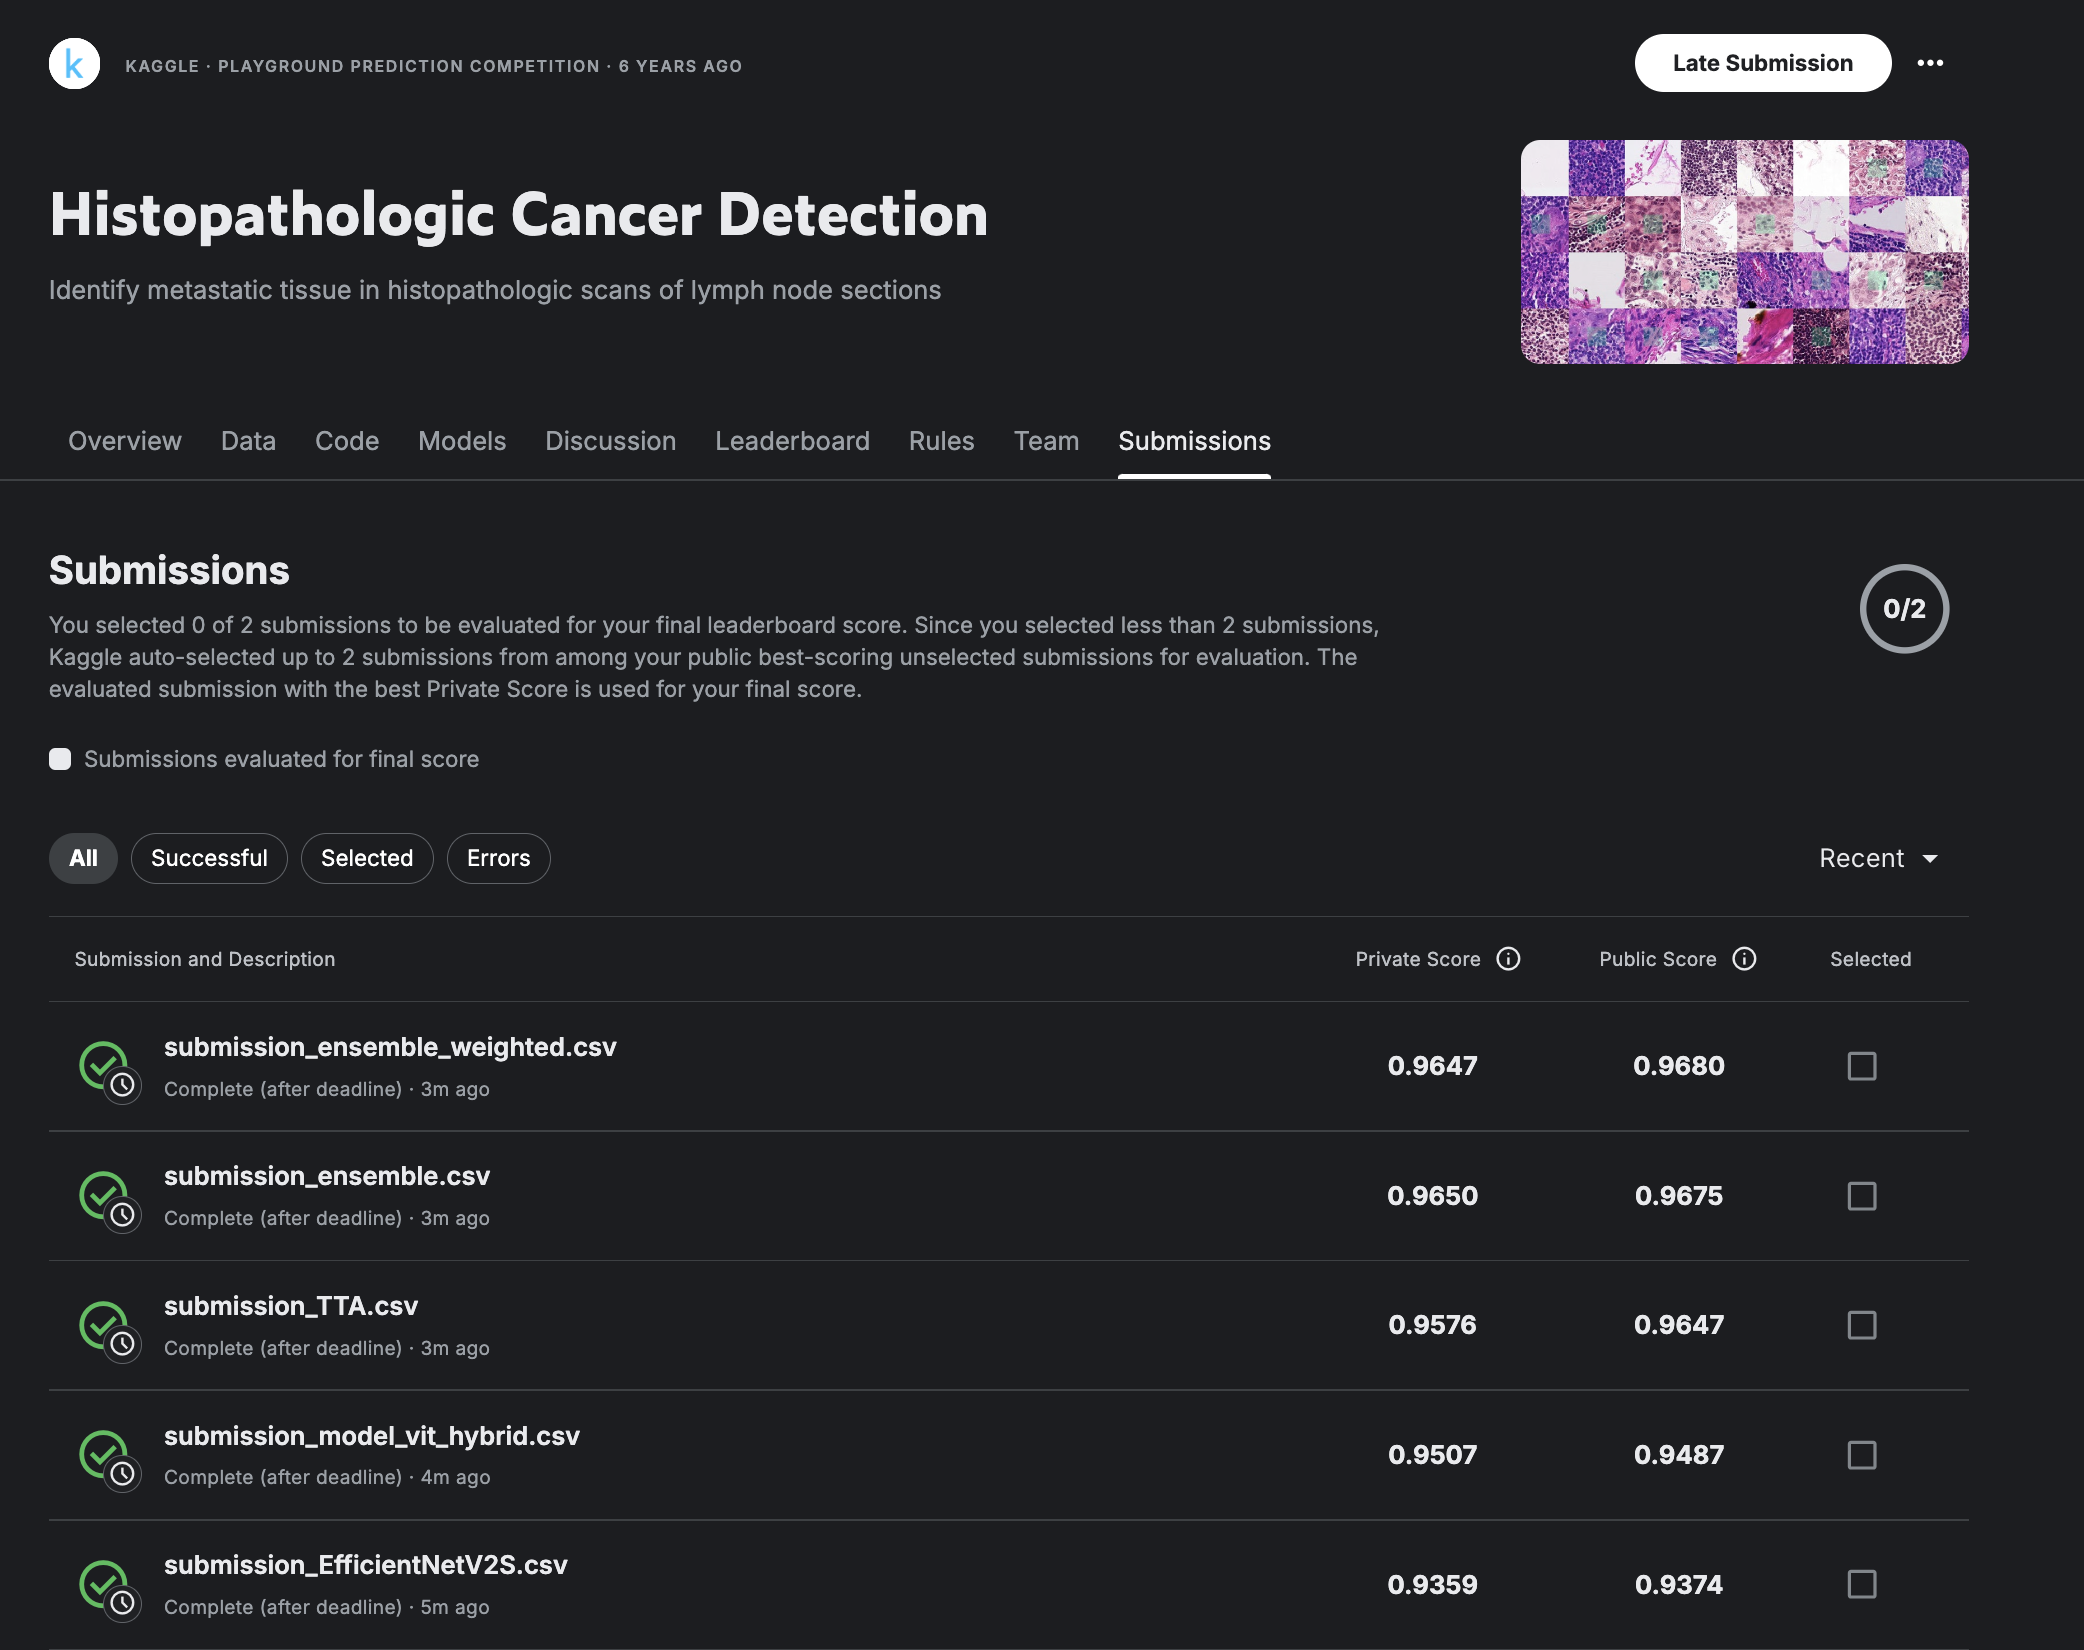

The ViT-Hybrid model with TTA achieved the best standalone performance, with a Private Score of 0.9576 and a Public Score of 0.9647, outperforming both EfficientNetV2S (0.9359 Private, 0.9374 Public) and the baseline ViT-Hybrid model (0.9507 Private, 0.9487 Public). Further improvements were achieved through ensemble averaging, where combining EfficientNetV2S, ViT-Hybrid, and TTA predictions led to a Private Score of 0.9650 and a Public Score of 0.9675. A weighted ensemble, giving the most weight to TTA predictions, performed similarly with a Private Score of 0.9647 and a Public Score of 0.9680, slightly refining generalization.

# Conclusions
This project shows the power of combining CNNs and Transformers for histopathologic cancer detection, with ViT-Hybrid outperforming EfficientNetV2S alone. While EfficientNetV2S captured local tissue structures, ViT’s self-attention mechanisms improved tumor region recognition. The One-Cycle Policy helped EfficientNetV2S converge efficiently, while ViT required gradual fine-tuning with cosine decay. Test-Time Augmentation (TTA) further improved robustness, validating that small image variations improve predictions. Ensemble averaging ultimately provided the best final performance, demonstrating the value of model diversity in medical imaging.

However, there are several areas for improvement. Augmentation strategies could be refined more by experimenting with stronger elastic deformations, contrast normalization, and stain augmentation techniques to increase generalization across different staining variations. Additionally, my stain normalization requires improvement, as the current implementation produced images that appeared too purple compared to StainTools examples. This could potentially cause errors in the color deconvolution process. The RuntimeWarning in exp() means there was numerical instability, likely due to large values in the stain matrix transformation. Addressing this by normalizing the concentration matrix or applying logarithmic stabilization could improve consistency.

Further improvements could include longer training schedules to allow ViT to fully converge. Additionally, implementing DeepSpeed or gradient checkpointing could help reduce memory overhead and improve the efficiency of training larger models. Exploring other CNN architectures like ResNet, ConvNeXt, or DenseNet could provide stronger baseline models, and ensembling them with ViT-Hybrid might further increase performance. Finally, extending TTA with more augmentations or using a weighted averaging technique based on confidence scores could also improve final predictions.

Overall, this project highlights the potential of hybrid architectures in medical image analysis and provides a strong foundation for future optimizations in augmentation, stain normalization, model efficiency, and ensembling techniques.

# Citations

### Papers
Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2021, June 3). An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale. arXiv preprint arXiv:2010.11929. https://arxiv.org/pdf/2010.11929

Smith, L. N. (2017, April 4). Cyclical Learning Rates for Training Neural Networks. arXiv preprint arXiv:1506.01186. https://arxiv.org/pdf/1506.01186

Smith, L. N. (2018, April 24). A Disciplined Approach to Neural Network Hyper-Parameters: Part 1 – Learning Rate, Batch Size, Momentum, and Weight Decay. arXiv preprint arXiv:1803.09820. https://arxiv.org/pdf/1803.09820

Tan, M., & Le, Q. V. (2020, September 11). EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks. arXiv preprint arXiv:1905.11946. https://arxiv.org/pdf/1905.11946

### Website and Guides

GeeksforGeeks. (2024, June 28). Macenko Method for Normalizing Histology Slides for Quantitative Analysis. Retrieved from https://www.geeksforgeeks.org/macenko-method-for-normalizing-histology-slides-for-quantitative-analysis/

Python Software Foundation. (n.d.). Multiprocessing — Process-Based Parallelism. Python Documentation. Retrieved from https://docs.python.org/3/library/multiprocessing.html


TensorFlow. (n.d.). TensorFlow Keras guide. TensorFlow Documentation. Retrieved from https://www.tensorflow.org/guide/keras


Juvonene, J. (n.d.). A Complete ML Pipeline (FastAI). Kaggle. Retrieved from https://www.kaggle.com/code/qitvision/a-complete-ml-pipeline-fast-ai